In [12]:
import pandas as pd
pd.set_option("display.max_columns", None)   # 显示所有列
pd.set_option("display.max_rows", 200)       # 可选：显示更多行
pd.set_option("display.width", None)         # 自动适配宽度
pd.set_option("display.max_colwidth", None)  # 不截断单元格内容

In [1]:
####提取想要的分类信息，并提取序列信息####
import pandas as pd
import numpy as np
#读取官方的2 unique peptide的微蛋白#
sample_info_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/human-openprot-2_2-refprots+altprots+isoforms-min_2_pep-uniprot2022_06_01.tsv"

#meta = pd.read_excel(sample_info_file)
openprot_hsapiens_all_2pep = pd.read_csv(sample_info_file,sep='\t')
print(openprot_hsapiens_all_2pep.shape)
display(openprot_hsapiens_all_2pep.head())
df_2pep=openprot_hsapiens_all_2pep.copy()
# 3) 只保留 AltProt
alt_2pep = df_2pep[df_2pep["protein type"] == "AltProt"].copy()

# 4) 定义你关心的 4 类
def assign_group(row):
    ms = row["MS score"]
    te = row["TE Translation Event score"]
    
    if ms >= 2 and te == 0:
        return "MS++|Ribo-"
    elif ms == 1 and te == 0:
        return "MS+|Ribo-"
    else:
        return np.nan

alt_2pep["group"] = alt_2pep.apply(assign_group, axis=1)

# 5) 只保留这 4 类
alt4_2pep = alt_2pep[alt_2pep["group"].notna()].copy()

# 6) 看结果
print("原始表大小:", df_2pep.shape)
print("AltProt 数量:", alt_2pep.shape)
print("4 类 AltProt 数量:", alt4_2pep.shape)
print("\n各组数量：")
print(alt4_2pep["group"].value_counts(dropna=False))

# 7) 看后面提序列最关键的列是否存在
need_cols = [
    "protein accession (others)",
    "gene symbol",
    "transcript accession",
    "start transcript coordinates",
    "stop transcript coordinates",
    "protein length (a.a.)",
    "MS score",
    "TE Translation Event score",
    "group"
]

print("\n关键列是否都在：")
for c in need_cols:
    print(c, "->", c in alt4_2pep.columns)

# 8) 展示前几行
display(alt4_2pep[need_cols].head())


/tmp/ipykernel_584866/2245907617.py:8: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  openprot_hsapiens_all_2pep = pd.read_csv(sample_info_file,sep='\t')


(952313, 22)


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,transcript accession,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains
0,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F29,1.0,451329.0,...,NM_001005221.2,mRNA,CDS,248.0,350.0,2,0,-,-,0
1,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F16,1.0,686305.0,...,XM_024449992.2,mRNA,CDS,2743.0,2845.0,2,0,-,-,0
2,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F16,1.0,686305.0,...,XM_017002410.2,mRNA,CDS,2755.0,2857.0,2,0,-,-,0
3,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,3.0,OR4F16,1.0,686305.0,...,XM_017002408.2,mRNA,CDS,2973.0,3075.0,2,0,-,-,0
4,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F16,1.0,686305.0,...,XM_047431162.1,mRNA,CDS,2692.0,2794.0,2,0,-,-,0


原始表大小: (952313, 22)
AltProt 数量: (617172, 23)
4 类 AltProt 数量: (591692, 23)

各组数量：
group
MS++|Ribo-    591692
Name: count, dtype: int64

关键列是否都在：
protein accession (others) -> True
gene symbol -> True
transcript accession -> True
start transcript coordinates -> True
stop transcript coordinates -> True
protein length (a.a.) -> True
MS score -> True
TE Translation Event score -> True
group -> True


,protein accession (others),gene symbol,transcript accession,start transcript coordinates,stop transcript coordinates,protein length (a.a.),MS score,TE Translation Event score,group
0,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F29,NM_001005221.2,248.0,350.0,33,2,0,MS++|Ribo-
1,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_024449992.2,2743.0,2845.0,33,2,0,MS++|Ribo-
2,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_017002410.2,2755.0,2857.0,33,2,0,MS++|Ribo-
3,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_017002408.2,2973.0,3075.0,33,2,0,MS++|Ribo-
4,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_047431162.1,2692.0,2794.0,33,2,0,MS++|Ribo-


In [2]:
#合并大表alt4和小标2pep的alt4_2pep#
#alt4_combined=pd.concat([alt4,alt4_2pep])
alt4_combined=alt4_2pep

###去重复###
# 1) 只保留 Ensembl transcript
alt4_ens = alt4_combined.copy()
alt4_ens["transcript accession"] = alt4_ens["transcript accession"].astype(str).str.strip()
alt4_ens = alt4_ens[alt4_ens["transcript accession"].str.startswith("ENST", na=False)].copy()

print("只保留 ENST 后行数:", alt4_ens.shape[0])
print("唯一 protein accession 数:", alt4_ens["protein accession"].nunique())
display(alt4_ens[["protein accession", "transcript accession"]].head(10))
alt4_ens["tx_base"] = alt4_ens["transcript accession"].str.split(".").str[0]

##读取cDNA的fasta文件，引入transcript长度，然后去重##
from Bio import SeqIO
import pandas as pd

#cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.all.fa"
cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.ncrna.merge.fa"#这个是合并了cdna和ncrna之后的fa文件


# 1) 读取 fasta
tx_seq_dict = {}
tx_len_dict = {}

for record in SeqIO.parse(cdna_fasta, "fasta"):
    tx_id = record.id.split("|")[0]   # 保留完整 ENSTxxxx.x
    seq = str(record.seq).upper().replace("U", "T")
    
    tx_seq_dict[tx_id] = seq
    tx_len_dict[tx_id] = len(seq)

print("fasta中 transcript 数:", len(tx_seq_dict))

# 2) 直接用完整 accession 匹配
alt4_ens["transcript_length"] = alt4_ens["transcript accession"].map(tx_len_dict)

# 3) 检查匹配情况
print("\ntranscript_length 缺失情况：")
print(alt4_ens["transcript_length"].isna().value_counts())

print("\n匹配成功比例：", alt4_ens["transcript_length"].notna().mean())

# 4) 看前几行
display(
    alt4_ens[[
        "protein accession",
        "transcript accession",
        "transcript_length"
    ]].head(10)
)

# 5) 看没匹配到的（理论上应该接近 0）
not_found = alt4_ens[alt4_ens["transcript_length"].isna()]
display(not_found[["protein accession", "transcript accession"]].head(10))

alt4_ens_found=alt4_ens[alt4_ens['transcript_length'].notna()]
display(alt4_ens_found.head(10))

只保留 ENST 后行数: 218742
唯一 protein accession 数: 104028


,protein accession,transcript accession
8,IP_057218,ENST00000559128.1
9,IP_057218,ENST00000332831.5
10,IP_057218,ENST00000426406.4
11,IP_057218,ENST00000456475.1
12,IP_057218,ENST00000405102.1
13,IP_057218,ENST00000402444.2
14,IP_057218,ENST00000651688.1
15,IP_057218,ENST00000320901.4
16,IP_057218,ENST00000424047.1
17,IP_057218,ENST00000589943.1


fasta中 transcript 数: 267165

transcript_length 缺失情况：
transcript_length
False    217581
True       1161
Name: count, dtype: int64

匹配成功比例： 0.9946923773212277


,protein accession,transcript accession,transcript_length
8,IP_057218,ENST00000559128.1,938.0
9,IP_057218,ENST00000332831.5,939.0
10,IP_057218,ENST00000426406.4,939.0
11,IP_057218,ENST00000456475.1,995.0
12,IP_057218,ENST00000405102.1,938.0
13,IP_057218,ENST00000402444.2,931.0
14,IP_057218,ENST00000651688.1,938.0
15,IP_057218,ENST00000320901.4,939.0
16,IP_057218,ENST00000424047.1,938.0
17,IP_057218,ENST00000589943.1,937.0


,protein accession,transcript accession
57386,IP_084541,ENST00000624376.1
57391,IP_084542,ENST00000624376.1
92894,IP_098234,ENST00000624820.1
92896,IP_098238,ENST00000624820.1
93681,IP_099125,ENST00000622953.1
93683,IP_099128,ENST00000622953.1
132009,IP_114119,ENST00000625169.1
206693,IP_148604,ENST00000625120.1
252176,IP_169365,ENST00000623283.1
252369,IP_169668,ENST00000623046.1


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains,group,tx_base,transcript_length
8,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F28P,15.0,101876210.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000559128,938.0
9,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F16,1.0,686305.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000332831,939.0
10,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F29,1.0,451329.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000426406,939.0
11,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,3.0,OR4F3,5.0,181367533.0,...,267.0,369.0,2,0,-,-,0,MS++|Ribo-,ENST00000456475,995.0
12,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F1P,6.0,106507.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000405102,938.0
13,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F7P,6.0,170639852.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000402444,931.0
14,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F8BP,9.0,138320144.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000651688,938.0
15,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F21,8.0,166675.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000320901,939.0
16,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F2P,11.0,87237.0,...,248.0,350.0,2,0,-,-,0,MS++|Ribo-,ENST00000424047,938.0
17,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F8P,19.0,156867.0,...,247.0,349.0,2,0,-,-,0,MS++|Ribo-,ENST00000589943,937.0


In [4]:
# 先看去重前
print("去重前行数:", alt4_ens_found.shape[0])
print("唯一 protein accession 数:", alt4_ens_found["protein accession"].nunique())

# 按 transcript_length 从大到小排序，再按 protein accession 去重
alt4_ens_found_dedup = (
    alt4_ens_found
    .sort_values(["protein accession", "transcript_length"], ascending=[True, False])
    .drop_duplicates(subset=["protein accession"], keep="first")
    .copy()
)

# 看去重后
print("去重后行数:", alt4_ens_found_dedup.shape[0])

# 看前几行
display(
    alt4_ens_found_dedup[[
        "protein accession",
        "transcript accession",
        "transcript_length",
        "group"
    ]].head(10)
)
print(alt4_ens_found_dedup['group'].value_counts())

去重前行数: 217581
唯一 protein accession 数: 102930
去重后行数: 102930


,protein accession,transcript accession,transcript_length,group
11,IP_057218,ENST00000456475.1,995.0,MS++|Ribo-
22,IP_057225,ENST00000618323.5,3468.0,MS++|Ribo-
28,IP_057228,ENST00000327044.7,2757.0,MS++|Ribo-
37,IP_057233,ENST00000338591.8,2567.0,MS++|Ribo-
43,IP_057234,ENST00000338591.8,2567.0,MS++|Ribo-
48,IP_057235,ENST00000338591.8,2567.0,MS++|Ribo-
58,IP_057245,ENST00000379410.8,3176.0,MS++|Ribo-
69,IP_057246,ENST00000379410.8,3176.0,MS++|Ribo-
79,IP_057249,ENST00000379410.8,3176.0,MS++|Ribo-
100,IP_057257,ENST00000651234.1,7477.0,MS++|Ribo-


group
MS++|Ribo-    102930
Name: count, dtype: int64


In [5]:
# 先复制一份，避免改原表
ml_df = alt4_ens_found_dedup.copy()

# 1) 坐标转成数值
ml_df["start transcript coordinates"] = pd.to_numeric(
    ml_df["start transcript coordinates"], errors="coerce"
)
ml_df["stop transcript coordinates"] = pd.to_numeric(
    ml_df["stop transcript coordinates"], errors="coerce"
)

# 2) 提取序列函数
#UP_LEN = 50
#DOWN_LEN = 50

UP_LEN = 450
DOWN_LEN = 450

def extract_tx_seqs(row):
    tx_id = row["transcript accession"]
    start = row["start transcript coordinates"]
    stop = row["stop transcript coordinates"]
    
    # transcript 序列字典：你前面已经建立过 tx_seq_dict
    tx_seq = tx_seq_dict.get(tx_id, None)
    
    if tx_seq is None or pd.isna(start) or pd.isna(stop):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    # transcript 坐标通常按 1-based, inclusive 处理
    s = int(min(start, stop))
    e = int(max(start, stop))
    
    # 转成 python 切片
    s0 = s - 1
    e0 = e-1
    
    # 边界检查
    if s0 < 0 or e0 > len(tx_seq):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    orf_seq = tx_seq[s0:e0]
    up_seq = tx_seq[max(0, s0 - UP_LEN): s0]
    down_seq = tx_seq[e0: min(len(tx_seq), e0 + DOWN_LEN)]
    
    return pd.Series({
        "orf_rna_seq": orf_seq,
        "upstream_50nt": up_seq,
        "downstream_50nt": down_seq,
        "orf_nt_len": len(orf_seq),
        "seq_ok": 1
    })

# 3) 批量提取
seq_df = ml_df.apply(extract_tx_seqs, axis=1)
ml_df = pd.concat([ml_df, seq_df], axis=1)

# 4) 看结果
print("成功提取比例：", ml_df["seq_ok"].mean())
print("\nseq_ok 计数：")
print(ml_df["seq_ok"].value_counts(dropna=False))

display(
    ml_df[[
        "protein accession",
        "transcript accession",
        "start transcript coordinates",
        "stop transcript coordinates",
        "transcript_length",
        "orf_nt_len",
        "orf_rna_seq",
        "upstream_50nt",
        "downstream_50nt",
        "group"
    ]].head(10)
)
ml_df["protein length (a.a.)"] = pd.to_numeric(ml_df["protein length (a.a.)"], errors="coerce")
ml_df["expected_nt_len"] = ml_df["protein length (a.a.)"] * 3

display(
    ml_df[[
        "protein accession",
        "protein length (a.a.)",
        "expected_nt_len",
        "orf_nt_len",
        "group"
    ]].head(20)
)

成功提取比例： 1.0

seq_ok 计数：
seq_ok
1    102930
Name: count, dtype: int64


,protein accession,transcript accession,start transcript coordinates,stop transcript coordinates,transcript_length,orf_nt_len,orf_rna_seq,upstream_50nt,downstream_50nt,group
11,IP_057218,ENST00000456475.1,267.0,369.0,995.0,102,ATGACCTGTTCAGAAAGCGCAAAGTCATCTCCTTTGGAGGCTGCAT...,AGCCCAGTTGGCTGGACCAATGGATGGAGAGAATCACTCAGTGGTA...,CCATGGCCTTTGACAGATATGTGGCCCTATGTAAGCCCCTCCACTA...,MS++|Ribo-
22,IP_057225,ENST00000618323.5,3105.0,3363.0,3468.0,258,ATGGCCCTGCCTCCCACCGCTTTATTTCTTTCGGTTTCGGATGCAA...,GTGGGGGGCCTGTCTGGCTGTGGAGAGTACACTCGGGTCTTCAGGG...,CTTCAGCAGCCCACAGCTGTGGGGCTTCAGCAGCCACACCAGCCCA...,MS++|Ribo-
28,IP_057228,ENST00000327044.7,528.0,873.0,2757.0,345,ATGAAGTGGTACAGGCGTTCCGAGCAGCTGTGGCCACCACCCGAGG...,CTTCGGGCTTTGACTCCGAGTCCGAATCCGAGTCCGAAAATTCTCC...,CCTTCCCCAAGCAGTGCCGCATGCTGCTCAAGAGAATGGTGATCGT...,MS++|Ribo-
37,IP_057233,ENST00000338591.8,715.0,817.0,2567.0,102,ATGCGCACTCCTGCAGCGACCTGCTCAAGGCCGCCCACAGGTACGT...,CCATGGAGGGAGCCGTGCAGCTGCTGAGCCGCGAGGGCCACAGCGT...,AACAGGTTCTGGAACTGGTCTCTAGCGACAGCCTGAACGTGCCTTC...,MS++|Ribo-
43,IP_057234,ENST00000338591.8,1819.0,2161.0,2567.0,342,ATGACCTGGTGGCCATGGACGGATGGTTGTACGCCGTGGGGGGTAA...,TGTCCATGGGCACAAGGCGAAGCTGCCTGGGTGTGGCCGCCTTGCA...,TTGTTTATTTATTTAGTTATTTATCTTATTTATTGAGGGGTGAGGA...,MS++|Ribo-
48,IP_057235,ENST00000338591.8,1534.0,1633.0,2567.0,99,ATGTGCGAGTGGCCACGCTTGATGGGAACCTGTATGCTGTGGGCGG...,GCGTCCTAGGCACCAGCCGCACACGTCCCCGGCGCTGCGAGGGGGC...,ACGTGTGGTCGCCCGTGGCGTCCATGCTGAGCCGACGCAGCTCAGC...,MS++|Ribo-
58,IP_057245,ENST00000379410.8,1375.0,1750.0,3176.0,375,ATGCCCCTGACCACACTTCGGAAACATCACACTCGCCCCTCTATGC...,TCAACACCATCCGCGTGGTGTGCGCCAGCTACGAGGACTACGGTCA...,CAGATGGTCGGTCCCCCAGGAGGAGCCGGGACCCCGGCTACGACCA...,MS++|Ribo-
69,IP_057246,ENST00000379410.8,1753.0,1951.0,3176.0,198,ATGGTCGGTCCCCCAGGAGGAGCCGGGACCCCGGCTACGACCACCT...,GCCGCGGCCCTGTCACCCCACTGCACCTGGACCTGACCCAGCTGCA...,CCCACTTCAAATTACAAGTCAGGGTCTGAACCCAGTGTGATGGGGG...,MS++|Ribo-
79,IP_057249,ENST00000379410.8,2279.0,2396.0,3176.0,117,ATGAGGGTCACAGGTCAGCAAGGTGTGAGGAGCACAAGCCAGGGTG...,GAAGTGCCCCCAGCTTGGAGGGCCTGAGGCCAGTGGGGGGCTTGTG...,CACCACCGGACGAGAAAGAAAAAAGAGAGAAGAGAGAGAGGAGAAG...,MS++|Ribo-
100,IP_057257,ENST00000651234.1,644.0,890.0,7477.0,246,ATGCGTGCCGGGGAATGCTGTGCGGCTTCGGCGCCGTGTGCGAGCC...,TCCTCCGCCTACCTCGGAGCCCACATTTGGGATTTCTACTCCGGGA...,CCTGCAGCTTCGGCAGCACCTGTGCGCGCTCGGCCGACGGGCTGAC...,MS++|Ribo-


,protein accession,protein length (a.a.),expected_nt_len,orf_nt_len,group
11,IP_057218,33,99,102,MS++|Ribo-
22,IP_057225,85,255,258,MS++|Ribo-
28,IP_057228,114,342,345,MS++|Ribo-
37,IP_057233,33,99,102,MS++|Ribo-
43,IP_057234,113,339,342,MS++|Ribo-
48,IP_057235,32,96,99,MS++|Ribo-
58,IP_057245,124,372,375,MS++|Ribo-
69,IP_057246,65,195,198,MS++|Ribo-
79,IP_057249,38,114,117,MS++|Ribo-
100,IP_057257,81,243,246,MS++|Ribo-


In [28]:
# 保存用于训练的数据（带长度筛选和随机抽样）
import os
import json
import pandas as pd
import numpy as np

out_dir = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom"
os.makedirs(out_dir, exist_ok=True)

# 选取原始列
train_df = ml_df[[
    "protein accession",
    "transcript accession",
    "protein length (a.a.)",
    "orf_rna_seq",
    "upstream_50nt",
    "downstream_50nt",
    "orf_nt_len",
    "group"
]].copy()

# -------------------
# 序列清洗函数
# -------------------
def clean_seq(seq):
    if pd.isna(seq):
        return pd.NA
    seq = str(seq).upper().replace("U", "T")
    seq = "".join([x for x in seq if x in set("ATCGN")])
    return seq if len(seq) > 0 else pd.NA

for col in ["orf_rna_seq", "upstream_50nt", "downstream_50nt"]:
    train_df[col] = train_df[col].apply(clean_seq)

train_df["orf_nt_len"] = train_df["orf_rna_seq"].apply(lambda x: len(x) if pd.notna(x) else np.nan)

# -------------------
# 原始过滤
# -------------------
train_df = train_df[
    train_df["orf_rna_seq"].notna() &
    train_df["group"].notna() &
    (train_df["orf_nt_len"] >= 3)
].copy()

# -------------------
# 筛选 protein length 30-150 aa
# -------------------
train_df["protein_len_aa"] = pd.to_numeric(train_df["protein length (a.a.)"], errors="coerce")
train_df = train_df[(train_df["protein_len_aa"] >= 30) & (train_df["protein_len_aa"] <= 150)].copy()

# -------------------
# 对 group 列随机采样
# -------------------
# MS++|Ribo- 随机取样 20000
mspp_ribo_minus = train_df[train_df["group"] == "MS++|Ribo-"]
if len(mspp_ribo_minus) > 20095:
    mspp_ribo_minus = mspp_ribo_minus.sample(20095, random_state=42)

# 其他 group 全部保留
other_groups = train_df[train_df["group"] != "MS++|Ribo-"]

# 合并
train_df = pd.concat([mspp_ribo_minus, other_groups], axis=0).reset_index(drop=True)

# -------------------
# 重命名列
# -------------------
train_df = train_df.rename(columns={
    "protein accession": "protein_accession",
    "transcript accession": "transcript_accession",
    "protein length (a.a.)": "protein_len_aa",
    "orf_rna_seq": "orf_seq",
    "upstream_50nt": "upstream_seq_50nt",
    "downstream_50nt": "downstream_seq_50nt",
    "group": "label_raw"
})

train_df = train_df.reset_index(drop=True)
train_df.insert(0, "sample_id", [f"sample_{i:07d}" for i in range(len(train_df))])

# -------------------
# label id 映射
# -------------------
label_order = sorted(train_df["label_raw"].astype(str).unique().tolist())
label_map = {lab: i for i, lab in enumerate(label_order)}
train_df["label_id"] = train_df["label_raw"].map(label_map).astype(int)

# -------------------
# 强制转成字符串列
# -------------------
for col in ["sample_id", "protein_accession", "transcript_accession",
            "orf_seq", "upstream_seq_50nt", "downstream_seq_50nt", "label_raw"]:
    train_df[col] = train_df[col].astype("string").astype(str)

train_df["orf_nt_len"] = pd.to_numeric(train_df["orf_nt_len"], errors="coerce")
train_df["label_id"] = pd.to_numeric(train_df["label_id"], errors="coerce").astype(int)

####去掉JC数据集中的小蛋白####
jc_file = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz"
jc_df = pd.read_csv(jc_file, dtype="string")
# 根据实际列名修改
jc_ids = set(
    jc_df["sample_id"]
    .dropna()
    .str.strip()
)
before = len(train_df)
train_df = train_df[
    ~train_df["protein_accession"]
    .astype("string")
    .str.strip()
    .isin(jc_ids)
].copy()

print("与 JC 重复并删除的数量:", before - len(train_df))
print("删除后剩余数量:", len(train_df))

train_df['sample_id'] = train_df['protein_accession']

# -------------------
# 输出
# -------------------
csv_gz_path = os.path.join(out_dir, "train_table_pos.csv.gz")
pkl_path = os.path.join(out_dir, "train_table_pos.pkl")
summary_path = os.path.join(out_dir, "train_table_pos_summary.json")

train_df.to_csv(csv_gz_path, index=False, compression="gzip")
train_df.to_pickle(pkl_path)

summary = {
    "n_rows": int(train_df.shape[0]),
    "n_cols": int(train_df.shape[1]),
    "columns": train_df.columns.tolist(),
    "label_order": label_order,
    "label_map": label_map,
    "label_raw_counts": {
        str(k): int(v) for k, v in train_df["label_raw"].value_counts().to_dict().items()
    }
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("导出完成：")
print(csv_gz_path)
print(pkl_path)
print(summary_path)

print("\nlabel_map:")
print(label_map)

print("\nlabel_raw 分布：")
print(train_df["label_raw"].value_counts())

display(train_df.head())

与 JC 重复并删除的数量: 95
删除后剩余数量: 20000
导出完成：
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/train_table_pos.csv.gz
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/train_table_pos.pkl
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/train_table_pos_summary.json

label_map:
{'MS++|Ribo-': 0}

label_raw 分布：
label_raw
MS++|Ribo-    20000
Name: count, dtype: int64


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_aa,label_id
0,IP_3787180,IP_3787180,ENST00000680249.1,108,ATGCTGCTGAAAAGATACCCGAAAACAGGGAAGCAACTTTGGAACTGGGTAACAGACAGAGGTTGGAACAGTTTGGAGGGCTCAAAAGAAGCCAGAACAATGTGGGAAAGTTTGGAATGCCCTAGAGACTTGTTGAATGGCTTTGCCCAAAATGCAGATAGCAATATGGACAATAAAGTCCAGGCTAAGGTGGTCTCAAATGGAGATGAGGAACTTGTTGGGAACTGTAGCAAAGGTGACTCTTGTTATGTTTTAGCAAAGTGGCTGGCAGCATTTTGCCCCACCCTAGAGATTTGTGGAACTTTGAACTTGAGAGAGATGATTTAG,ATTCCTCCTTATAATACCATCAGATATTATGATACTTATTTGCTATCACAAGAACAGCACTCAGATATTATGAGACTTATTTGCTATCAGAAAAATAGCACATGCCCCCATGATTCAATTACCTCCCACTGAGTTCCTCCTACAACACGTGGGAATTCAAGATGAGATTTGGGTGGGGACATACCCAAACCATATCACCTCTTTTTCTTCCCAGTCTCAGGTATGTCTTTAGCAGCAGCAGGAATACAGACTAATACAGTAAATTGGAACCAATAGAGTGGG,GGAATCTGGTGGAAGAAATTTCTAAGCAGCAAAGCATTCAAGAGGTGACTTGGGTGCTGTTAAAGGCATTCAGTTTTATAAAGAAATCAGAGCATAAAAGTTCAGAAATTTGCAGCCTGACAAGGTGATAGGGAAGAAAATTCCATTTTCTGAGGAGAAATTTAAGCTGGCTGCAGAAGTTTGCATAAGTAACGAGGAGCTGAATGTGAATCATTGCCAAGACAATGGGGAAAATGTCTCCAGCGAATGTCAGTAGTCTTCAAGGTAGCCCCTCCCATCACAGGCCTGGAAGCCTAGGAGGGAAAAATGGTTTCATTGGCTGGGCCCAGTGTCCCTCTGCTGTGTGCAGTCTAAGGACTTAGCGCCCTGTGTCCCAGCCACTCCAGCCATGACTACAAGGGGCCAAGCTAGAGCTCAGGTTGTGGCTTCAGAGGGTGCAAGCTCCAAGCC,327,MS++|Ribo-,108,0
1,IP_664307,IP_664307,ENST00000494955.1,90,ATGGTGCTGTACCCACTTTTTGTTAATGATATTTATAGAGGCTATAGCACCTCAAAAAGCCCTGGGATAGTCTGGGAAGCCAACCCTAAGAAAGTGGTGCAGGAGCTGGTCCTTTACTTTGAGAAGTTTGGAGAGGAAGGAGGACTTCCCAGGTTTGGTGGTCAAAGCCTGGGCAGCTGGTGTAGCTGTGGCATCTTGTGTAAGTGTGGGCCGGCTGCTGAGTCAGCATGTCACACTAGACCTCCAGACAGCCCTGCCAGGGGAGTCAACTGA,ATGAGTTCAAGCAGTTCTCCTGCCTCATCCTCCCAAAGTATTGGGATTACAGGCATGAGCCGTGACAC,GGCTCAGGGGTGACACAGCTGGTTTGCAGTCGCACATGGGAGCCAGAATGAGTGTGGACCAGCCCTGCTCACAGGCCAAAGTGGGGCCCATGGGGGTGGGCCTGTTGCTGGGACCCCCTCCCCAGGAGGTGTGACCCTTCCCCATCTCTGCCCAGACTGCATCACTGTGACCAGTGCTGAGGATGGCGGGGCCGAGACCACACGGTACCTGATCCTACAGGGCCCAGATGATGGTAAGACCCCAGGTGCCAGAATCGGGGAGGCCTGCAGTGGGCAGGGGGATAGGTGAGGACAGGTTCTGCCGCGGATTCCGTCTGTGGCCCTGGCTGGGTATCCACTGCTCTGGGTCTCAGTTTTCCTACTGACGGGTTGGCCTCTGGTGGGGAATTTGGTTCTGCACTCCCTGGGCCTGCCTGGGAGGGGTAGCTATAGCTCATGGCCAGTGCTGCC,273,MS++|Ribo-,90,0
2,IP_2370990,IP_2370990,ENST00000695368.1,44,ATGTTCAGGATATTAAATACTATTAAATTCTACCTCATTAGGTACAGCACTACAGCCTATGGAGACCTATCTATCCACCTCAGAGTAAGGAAATCAACAAAGATGATAAACTTCTATCTTCATCCAAGTCACTAA,TCTTTTTATAGCCACACCGTCTTCATCGCCTGAATTGATCTCAAATATTTAAAGATGGCTTTCATATCTTCCATGAGTTATTTTCTCCTGAAAGCAAAAAATCCCACTTGAAATACAAAATAGTTCAGTCTTTTCACAATTCTAATCACTGTTCTCCAAATTTGCTCCCAAGCCTAAGTTTCTTAGAAAGTTTAATGTCTAGGATTGACCATAATAAACACTTACGTATAGTTCATCTCTGCCTAACAGAGCTCCACTATCAACTTCCTCATTACACAAAGTATATTTATTTTAATATAACTTGCAATACTATTACATTCTTTGTTGGCCATAGCATACTAGTAATTCAGATTGAGATGTACTTTCTACTAAAACTTTAAAAATTCTAAATGCACTATTGTTAAGCAAATTCTGTCTTTCTACTGCCCTTGATCATTTGAGTTTTATTGT,CAAAAACTACCATGCAGAATCAGGTTGAGGATAAATCTCCAGAATAATAGTAATAGAGACAGTGTGTAAAGTACTGACAAAAGCAAAAGATGACAATTACTAAGCCCTTTTATGTTCCAGATTCTGTATCACACTCCACAACAAACTCCCACATACCACCCTCGAAATATCTACTAATACTTGTTGATGTGCTTATTCACTAATTCGTTGTTTAAAAGATTATTATTAAGCATCTATTATATATGAGTTACTGAGCTACTTGTTAATGATAGAAAAGTGAATAAAATGTGGCTCCGTTTCTCACATTACTAGCAGCCAACTGATTACTCTTCCTCTTTTCTACACACACAGCACAAAAGACACAATCAGATGTATTTGCAGGATATATTTTTTTCCCATGTAAAACATTTGCCTGACATCATAGTCATCTTTAGTAAGAAAACTGGGATA,135,MS++|Ribo-,44,0
3,IP_070099,IP_070099,ENST00000439374.6,50,ATGACATTCCATTTAAGTTTTGGGGCATCTTTCCTGCCCTCTGCCAACCTCCCTGCTGGCCCAGGTGAGAGGAGGAAGAGGGGTCTGGAAAGAAACCCAGAATGCGGCAGAACTAGGAGTAAGTCCATCTCAAGGTGGACTTCTGATCATTGA,TGCCACCTGTTTTTAAACTCTTAAACCTGGAACTCCTTAAATGGGGTAGGTGGGTGAGATTATCAAAGCTGAAGCTGGCTTTGCTGAGAAGCTCCCTACCTCCCTGCCCTTCTCCTCCTTCCTGCTGGAATGAACTAAAGCAGATGTCAAGCAGGGGCTGGTGGGGGTGCCTACTCCCTTTTCCACTCTATCTTTAGATTTCAAACCTTAGGCTTACAGCCCCTCAATATCTCTCTGCTAACACCAGTGTCTCTTTCTAGTTAGGCCTCTAATCTTCTGTTTCTGTTTACCAGCTTCCCAGCAACTTTCCTTTTTTAAAATATTAAAAATTTAATTCAGGTTCTCTTAATTATCCTCATCCTGCTGTTGCCTCCGCCCTTAACTCTATCCCTATTAGGAACCTTGTTTCCCACCGAATAAGAGTTAAGGTAAGAGGTAGCTCTTCACCTG,GGATGGTGAGATAAATAGGTTGAAAACAATCATCTGTGAGTTTAGGAGTCTTAAGATCCTCACAGCACGGGAGCAGGGAGAGGCTCTAGAACAAGGTTTCACAACCG

In [18]:
jc_file = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz"
#jc_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/openprot_info/test_table_JC.csv.gz"
jc_df = pd.read_csv(jc_file, dtype="string")

In [21]:
display(jc_df.head())
display(train_df.head())

,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
0,IP_060425,<NA>,<NA>,42,ATGGCTCATAGGATTGCTGTAAGGTCTCAATTACTAGGGGCTTCCAGGGCATTTCTGAGAAATAACCCTGGGTCCTTGTCTAGACCCTTATGCCAGACCCCACTCCAAAGAGCGGTAAGAATTCCTTAG,TATCATGGAAAACATAAGTGACGATGTGATTGTTGGCCGATGCCTGGCCATTCTCAAAGGGATTTTTGGTAGCAGTGCAGTACCTCAGCCCAAAGAAACTGTGGTGTCTCGTTGGCGTGCTGATCCCTGGGCTCGGGGCTCTTATTCCTATGTTGCTGCAGGATCATCTGGAAATGACTATGATTTAATGGCTCAGCCAATCACTCCTGGCCCCTCGATTCCAGGTGCCCCACAGATTTTAGTCATTCCATCTTCGGACCCTTTCAGATAACCAAGAGCAGAGTTAAAAGGATGGGCAGCATTTCTGATTTCTCATAATTTGGTTTTGTAAATCTAGGCAGTCTACATTCAGAATGGAGGAGTCCAGAGTATAAGTCAAATAACATTTTTCCTTATTCAGGTTTTCTCCCTAAAAAACAAAACCATTTTTAATTGCACTTCCATTTTGTA,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGATCACCAAATGTCCTGTGCTTCAGGGTAGCGAGGCTCCCTCCCAGAAGGTAGTTATACATGAGGGAAGGACGCTTTACAACTGGGTATCTAAACTGATGAGAACACATGTTAAGCATCACTTTAGGACTGAGCCTAGGTAGAGTTTTATTGTCTCATTTCTACTTGTCAATTCTGGGAAAGTGCCTACTGATAAGGGAGACTCTTCGATAGAATGATGAATAGTAATTGGGGGGGTCAGCCTTTAAAAAGGTCAACAGCAATTTAAGTACTTAGCAATTTAAGTACAAGAATAAAGGTATATGTGCAGCCTGCCAATTTTCTCTTTTTCCCCTAAAATAGCCGATTCCACGACTCTTCTTTGCGGGAGAACATACGATCCGTAACTACCCAGCCACAGTGCATGG,129,MS+|Ribo-,42,9
1,IP_062202,<NA>,<NA>,64,ATGAGGATGAAGACCAGATTTCAGAGCAGGACATTTTTGAGGGTTTGCCTGGAGCCTTATCAAAATGTCCTACAGAAGCTGTTTGCCAACCTCTTGACTGGGGAGAAGACAGTGAAAATGAAAATGAAGATGAAGGGCAGTGGGGAAATCCCTCACAGGAACAGTGGCAAGAAAGTTCTTCTGAAGAGGACTTAG,GTATTGCAGGTGTGCACTGGGGCTATGAGGAGACCAAGGCCTTCCTGGCAATTCTCAGTGAGTCCCCATTCTCGGAAAAGCTTCGTACCTGTCACCAGAACAGCCAGGTGTACCGGGCCATTGCAGAGCGGCTGTGTGCTCTGGGCTTCCTGCGGACACTGGAGCAGTGTCGCTACAGATTCAAAAACCTCCTTCGAAGCTACCGGAAAGCCAAGAGCAGCCACCCACCAGGGACATGCCCTTTCTATGAGGAACTGGACTCGCTGATGAGGGCTCGGGCTGCAGTCAGGGCCATGGGGACTGTCCGAGAGGCTGCAGGTCTCCCTAGGTGTGGGCAGAGTAGTGCTGAGACTGATGCCCAGGAGGCCTGGGGTGAAGTGGCCAATGAAGATGCTGTCAAACCTTCAACCTTGTGTCCTAAAGCCCCAGACATGGGTTTTGAAATGAGGC,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTACAAGTGTGACACATGCATGAAGAGCTTCAGTCGGAGCTCCCACTTCATTGCCCATCAGCGAATCCACACAGGTGAGAAGCCCTACAAATGCCTTGAATGTGGAAAAAACTTTAGTGACCGCTCTAACCTCAATACCCATCAGAGAATCCACACTGGAGAGAAGCCCTATAAATGCCTTGAATGTGGGAAAAGCTTTAGTGACCATTCTAATCTCATCACTCACCAGAGAATTCACACGGGGGAAAAGCCCTATAAATGTGGAGAATGTTGGAAAAGCTTCAACCAGAGCTCAAACCTTCTGAAACATCAGAGAATCCACTTGGGAGGAAATCCTGACCAGTGTAGTGAGCCTGGGGGAAACTTTGCCCAAAGCCCATCTTTTAGTGCTCACTGGAGGAATTCTA,195,MS+|Ribo-,64,9
2,IP_062563,<NA>,<NA>,155,ATGAGCACTCTTCCCTTTCTCCCCTTCCACCTGCTGCGGGCTGGGCTGGTTTTCTCAATACAAAATTGTAAGAGGATCCTTGTCACCCCAGCCAGGTATCCCCAAGGCAGAGCACCTCTCGTTTGGCCCTCTGAACAAGGTGCACGCGAGCTGGGGGATGAAGACGGCTCCCACTTCCTTTTCCTTAATAAGAACCATATGGTGGGTGTATGTGTGTACAAGAGGGGTTCATCTGTGGGGGCTTCCTCTCCTTCCACCCTCTGGTTCCAATTTCCTGTTCTAAGCAGGACTAGGGCCCAGGAGGCTAAGGCTGGGAGAGAAAGGGTGCCAACAGGTCCCTTGGGAATGAGTTGGCTCTGGACGTTTCTGCCCTGTTCCCCGATCAGAGCTCCTCTGCAGGAAACAGGCAGGATGCCCCTCCCAACCCCTCAGTCCCTACGTCAAGCGGAGTGGATAAGGCTGAGATGA,AGCTCCCCCTGGGACCTCCAGCATATGACAGTGGACTAAGGACTGTGGGGTTTTCCTCCAAGGGGAAGGGAGAAGAGGGGACCATCGAGGTGGCGAGTGTGGACACCCTGCCAGGACTGCAGCCCCCATGGTGATGCTGTGGCATCAGACATGTCCGTGGTGGGCACAGTGCCTGTTGCCCTGGGAAAGGGCAACCTCCCTTTCACTGCTCCAGTGGCAGCCATGGGGAAGGCAGTTTGTGAGGGCTTGGGGCACAGACCTGGGGCAGGAGGCAGCTCTTCACGTTCATCCCTGTCTCTCCCGGGCTGCCCCCGCCAGCTCTGGCTGTTTAGCTTGAGGGCAGCACAGAGGCCCCTGGGACACCTACAGGCCAGAAAGATCAACCTCTGTGAAGTGTCTAGAAGTATCTAGTGCAGATGGTGGCGGAGGCAGAATCGACCATCAGCAAAC,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTTTCCCCGCAGCTGCAGGGCCTCGCGCTCGGCCCTCGCCAGGCCAGCCCCACTCCTTGTACCAAGTGTGAACTGGGGTCATTCGGTCTGTGATCTCGTTGCACTGCTCCAAGTCTGGCTGTGTCCAGGCGGTCCATGTTGAAAATGGAGGATGGCTGCTGACTTCTGACTGGCTGAGCAGTGGGTTCCTTCAGGTTCCTTGCCAACCCTCCTCCCCTGCCCACAACTTCTCCAAACAAAGCAGGCTGTTTGCTCACTTCTTCAAAAGGAGGAATGATAACCCAAATCTGCCCAAGTGACACTTGAGAAGGTTTTGGCTGGGGTTCCTGGTGGATTTCTTACTACCTAACGCCCAAGAAAACCAACTAAGGACTCTCAAACCATACCTGGTGGGGGTTCTTCGCTCA,468,MS++|Ribo-,155,9
3,IP_062720,<NA>,<NA>,38,ATGGAGGGGCAGGTTTTGAACAGGGGAGGGAGGTTCTGGGGATTCTGGATGAGAACTGGGGCATACCAGCCACTCCCCTCCCACCTCTGTCCCATGCTGCTTGGGAAGCCCGGTTAG,ACAGACTAACTTTGGGCTAGGTGAGGGAAACCAGAAGAGACCAAAAGAACTTCTGGTCTCCTGGAC

,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_aa,label_id
0,sample_0000000,IP_3787180,ENST00000680249.1,108,ATGCTGCTGAAAAGATACCCGAAAACAGGGAAGCAACTTTGGAACTGGGTAACAGACAGAGGTTGGAACAGTTTGGAGGGCTCAAAAGAAGCCAGAACAATGTGGGAAAGTTTGGAATGCCCTAGAGACTTGTTGAATGGCTTTGCCCAAAATGCAGATAGCAATATGGACAATAAAGTCCAGGCTAAGGTGGTCTCAAATGGAGATGAGGAACTTGTTGGGAACTGTAGCAAAGGTGACTCTTGTTATGTTTTAGCAAAGTGGCTGGCAGCATTTTGCCCCACCCTAGAGATTTGTGGAACTTTGAACTTGAGAGAGATGATTTAG,ATTCCTCCTTATAATACCATCAGATATTATGATACTTATTTGCTATCACAAGAACAGCACTCAGATATTATGAGACTTATTTGCTATCAGAAAAATAGCACATGCCCCCATGATTCAATTACCTCCCACTGAGTTCCTCCTACAACACGTGGGAATTCAAGATGAGATTTGGGTGGGGACATACCCAAACCATATCACCTCTTTTTCTTCCCAGTCTCAGGTATGTCTTTAGCAGCAGCAGGAATACAGACTAATACAGTAAATTGGAACCAATAGAGTGGG,GGAATCTGGTGGAAGAAATTTCTAAGCAGCAAAGCATTCAAGAGGTGACTTGGGTGCTGTTAAAGGCATTCAGTTTTATAAAGAAATCAGAGCATAAAAGTTCAGAAATTTGCAGCCTGACAAGGTGATAGGGAAGAAAATTCCATTTTCTGAGGAGAAATTTAAGCTGGCTGCAGAAGTTTGCATAAGTAACGAGGAGCTGAATGTGAATCATTGCCAAGACAATGGGGAAAATGTCTCCAGCGAATGTCAGTAGTCTTCAAGGTAGCCCCTCCCATCACAGGCCTGGAAGCCTAGGAGGGAAAAATGGTTTCATTGGCTGGGCCCAGTGTCCCTCTGCTGTGTGCAGTCTAAGGACTTAGCGCCCTGTGTCCCAGCCACTCCAGCCATGACTACAAGGGGCCAAGCTAGAGCTCAGGTTGTGGCTTCAGAGGGTGCAAGCTCCAAGCC,327,MS++|Ribo-,108,0
1,sample_0000001,IP_664307,ENST00000494955.1,90,ATGGTGCTGTACCCACTTTTTGTTAATGATATTTATAGAGGCTATAGCACCTCAAAAAGCCCTGGGATAGTCTGGGAAGCCAACCCTAAGAAAGTGGTGCAGGAGCTGGTCCTTTACTTTGAGAAGTTTGGAGAGGAAGGAGGACTTCCCAGGTTTGGTGGTCAAAGCCTGGGCAGCTGGTGTAGCTGTGGCATCTTGTGTAAGTGTGGGCCGGCTGCTGAGTCAGCATGTCACACTAGACCTCCAGACAGCCCTGCCAGGGGAGTCAACTGA,ATGAGTTCAAGCAGTTCTCCTGCCTCATCCTCCCAAAGTATTGGGATTACAGGCATGAGCCGTGACAC,GGCTCAGGGGTGACACAGCTGGTTTGCAGTCGCACATGGGAGCCAGAATGAGTGTGGACCAGCCCTGCTCACAGGCCAAAGTGGGGCCCATGGGGGTGGGCCTGTTGCTGGGACCCCCTCCCCAGGAGGTGTGACCCTTCCCCATCTCTGCCCAGACTGCATCACTGTGACCAGTGCTGAGGATGGCGGGGCCGAGACCACACGGTACCTGATCCTACAGGGCCCAGATGATGGTAAGACCCCAGGTGCCAGAATCGGGGAGGCCTGCAGTGGGCAGGGGGATAGGTGAGGACAGGTTCTGCCGCGGATTCCGTCTGTGGCCCTGGCTGGGTATCCACTGCTCTGGGTCTCAGTTTTCCTACTGACGGGTTGGCCTCTGGTGGGGAATTTGGTTCTGCACTCCCTGGGCCTGCCTGGGAGGGGTAGCTATAGCTCATGGCCAGTGCTGCC,273,MS++|Ribo-,90,0
2,sample_0000002,IP_2370990,ENST00000695368.1,44,ATGTTCAGGATATTAAATACTATTAAATTCTACCTCATTAGGTACAGCACTACAGCCTATGGAGACCTATCTATCCACCTCAGAGTAAGGAAATCAACAAAGATGATAAACTTCTATCTTCATCCAAGTCACTAA,TCTTTTTATAGCCACACCGTCTTCATCGCCTGAATTGATCTCAAATATTTAAAGATGGCTTTCATATCTTCCATGAGTTATTTTCTCCTGAAAGCAAAAAATCCCACTTGAAATACAAAATAGTTCAGTCTTTTCACAATTCTAATCACTGTTCTCCAAATTTGCTCCCAAGCCTAAGTTTCTTAGAAAGTTTAATGTCTAGGATTGACCATAATAAACACTTACGTATAGTTCATCTCTGCCTAACAGAGCTCCACTATCAACTTCCTCATTACACAAAGTATATTTATTTTAATATAACTTGCAATACTATTACATTCTTTGTTGGCCATAGCATACTAGTAATTCAGATTGAGATGTACTTTCTACTAAAACTTTAAAAATTCTAAATGCACTATTGTTAAGCAAATTCTGTCTTTCTACTGCCCTTGATCATTTGAGTTTTATTGT,CAAAAACTACCATGCAGAATCAGGTTGAGGATAAATCTCCAGAATAATAGTAATAGAGACAGTGTGTAAAGTACTGACAAAAGCAAAAGATGACAATTACTAAGCCCTTTTATGTTCCAGATTCTGTATCACACTCCACAACAAACTCCCACATACCACCCTCGAAATATCTACTAATACTTGTTGATGTGCTTATTCACTAATTCGTTGTTTAAAAGATTATTATTAAGCATCTATTATATATGAGTTACTGAGCTACTTGTTAATGATAGAAAAGTGAATAAAATGTGGCTCCGTTTCTCACATTACTAGCAGCCAACTGATTACTCTTCCTCTTTTCTACACACACAGCACAAAAGACACAATCAGATGTATTTGCAGGATATATTTTTTTCCCATGTAAAACATTTGCCTGACATCATAGTCATCTTTAGTAAGAAAACTGGGATA,135,MS++|Ribo-,44,0
3,sample_0000003,IP_070099,ENST00000439374.6,50,ATGACATTCCATTTAAGTTTTGGGGCATCTTTCCTGCCCTCTGCCAACCTCCCTGCTGGCCCAGGTGAGAGGAGGAAGAGGGGTCTGGAAAGAAACCCAGAATGCGGCAGAACTAGGAGTAAGTCCATCTCAAGGTGGACTTCTGATCATTGA,TGCCACCTGTTTTTAAACTCTTAAACCTGGAACTCCTTAAATGGGGTAGGTGGGTGAGATTATCAAAGCTGAAGCTGGCTTTGCTGAGAAGCTCCCTACCTCCCTGCCCTTCTCCTCCTTCCTGCTGGAATGAACTAAAGCAGATGTCAAGCAGGGGCTGGTGGGGGTGCCTACTCCCTTTTCCACTCTATCTTTAGATTTCAAACCTTAGGCTTACAGCCCCTCAATATCTCTCTGCTAACACCAGTGTCTCTTTCTAGTTAGGCCTCTAATCTTCTGTTTCTGTTTACCAGCTTCCCAGCAACTTTCCTTTTTTAAAATATTAAAAATTTAATTCAGGTTCTCTTAATTATCCTCATCCTGCTGTTGCCTCCGCCCTTAACTCTATCCCTATTAGGAACCTTGTTTCCCACCGAATAAGAGTTAAGGTAAGAGGTAGCTCTTCACCTG,GGATGGTGAGATAAATAGGTTGAAAACAATCATCTGTGAGTTTAGGAGTCTTAAGATCCTCACAGCACGGGAGCAGGGAGAGGCTCTAG

In [25]:
test = pd.read_csv("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/ribotricer_clean_unused_after_10runs.csv.gz", dtype="string")
display(test.head())

,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id,orf_len,up_len,down_len,orf_bin,up_bin,down_bin,len_bin,binary_label,rnafm_up_path,rnafm_orf_path,rnafm_down_path
0,ENST00000405053_58993464_59893262_450,ENST00000405053_58993464_59893262_450,ENST00000405053,150,ATGGACCGCACCTCCTACGCGGTGGAGACCGGCCACCGGCCCGGCCTGAAGAAATCCAGGATGTCCTGGCCCTCCTCGTTCCAGGGACTCAGGCGTTTTGATGTGGACAATGGCACATCTGCGGGACGGAGTCCCTTGGATCCCATGACCAGCCCAGGATCCGGGCTAATTCTCCAAGCAAATTTTGTCCACAGTCAACGACGGGAGTCCTTCCTGTATCGATCCGACAGCGATTATGACCTCTCTCCAAAGTCTATGTCCCGGAACTCCTCCATTGCCAGTGATATACACGGAGATGACTTGATTGTGACTCCATTTGCTCAGGTCTTGGCCAGTCTGCGAACTGTACGAAACAACTTTGCTGCATTAACTAATTTGCAAGATCGAGCACCTAGCAAAAGATCACCCATGTGCAACCAACCATCCATCAACAAAGCCACCATAACAGTTTAA,AGCGCTACCTGTACTGTCGCGCC,AAGGATGCTTAATCGGGAGCTCACCCATCTCTCTGA,453,ribotricer,150,7,453,23,36,"(450.0, 480.0]","(-0.001, 50.0]","(-0.001, 50.0]","(450.0, 480.0]|(-0.001, 50.0]|(-0.001, 50.0]",0,/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg/upstream/ENST00000405053_58993464_59893262_450_upstream.pt,/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg/orf/ENST00000405053_58993464_59893262_450_orf.pt,/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg/downstream/ENST00000405053_58993464_59893262_450_downstream.pt
1,ENST00000683624_66379317_67180325_372,ENST00000683624_66379317_67180325_372,ENST00000683624,124,ATGAACAACGCTGGAAAAAAAGAAAGGAGTAATACCCTGAATATTGCTTTAGACAACATGTGTAAGAAGACAAGAGACCTTCGCAGACAGCTCCGCAAGGCTATTATAGATCATGTGTCAGACTCTTTCCTGGATACGACAGTCCCTCTTTTGGTTCTCATTGAAGCTGCTAAGAATGGCCGGGAAAAGGAAATAAAAGAATATGCTGCGATATTTCATGAACACACCAGCAGGCTTGTAGAGGTGGCAAATCTTGCTTGTTCCATGTCAACAAATGAAGATGGAATTAAAATTGTCAAAATTGCAGCCAATCATTTGGAAACCTTGTGTCCACAGAAAGCCATATCTTGGAAGATGTCAACAAGTGTATCATAG,TCTCCAAATCAGAGAGATGAAATTGCAGGAGCCCGAGCTTCACTGAAGGAGAACTCTCCCCTCTTGCATTCAATTTGTTCAGCTTGTTTGGAGCATTCTGATGTTGCTTCCCTCAAAGCAAGCAAGGACACAGTTTGTGAAGAAATTCAGAATGCTCTCAATGTAATTTCAAATGCTTCACAAGGGATCCAGAATATGACAACCCCACCAGAACCTCAGGCAGCAACCCTGGGAAGTGCCCTTGATGAGCTGGAGAATTTAATTGTCCTGAATCCACTCACAGTAACTGAGGAGGAAATACGACCATCACTAGAGAAACGCCTTGAAGCCATTATCAGTGGGGCTGCTCTGCTGGCGGATTCTTCATGTACGAGGGACTTACACCGAGAGCGGATTATCGCAGAATGCAACGCCATTCGCCAGGCTCTTCAGGATCTGCTTTCAGAGTAC,CCTTAAGAGACCAGGATGCTGATAATTTAGACCGTGCTGCGGGTGCTATCAGAGGCCGGGCAGCAAGAGTTGCTCACATCGTCACGGGTGAAATGGACAGTTACGAGCCAGGGGCTTACACGGAAGGTGTAATGAGAAATGTTAACTTCCTTACAAGTACTGTAATTCCTGAATTTGTAACACAAGTGAATGTTGCCTTGGAAGCCTTAAGCAAAAGCTCATTGAATGTGTTGGATGATAATCAATTTGTGGACATCTCAAAGAAGATCTATGATACAATTCATGATATCAGATGTTCAGTCATGATGATTCGGACCCCAGAGGAACTGGAGGATGTTTCTGACCTTGAAGAGGAACACGAGGTCCGCAGTCACACCAGCATTCAGACCGAAGGGAAAACTGATAGGGCTAAGATGACTCAACTGCCTGAGGCAGAAAAAGAAAAGATTG,375,ribotricer,124,7,375,450,450,"(360.0, 390.0]","(400.0, 450.0]","(400.0, 450.0]","(360.0, 390.0]|(400.0, 450.0]|(400.0, 450.0]",0,/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg/upstream/ENST00000683624_66379317_67180325_372_upstream.pt,/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg/orf/ENST00000683624_66379317_67180325_372_orf.pt,/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg/downstream/ENST00000683624_66379317_67180325_372_downstream.pt
2,ENST00000569332_78432564_79211793_375,ENST00000569332_78432564_79211793_375,ENST00000569332,125,ATGCTGGCTTATAACAGGTCCAAGCTCTGCAACATCCTCTTCTCCAACGAGCTGCACCGTCGCCTCTCCCCACGCGGGGTCACGTCGAACGCAGTGCATCCTGGAAATATGATGTACTCCAACATTCATCGCAGCTGGTGGGTGTACACACTGCTGTTTACCTTGGCGAGGCCTTTCACCAAGTCCATGCAACAGGGAGCTGCCACCACCGTGTACTGTGCTGCTGTCCCAGAACTGGAGGGTCTGGGAGGGATGTACTTCAACAACTGCTGCCGCTGCATGCCCTCACCAGAAGCTCAGAGCGAAGAGACGGCCCGGACCCTGTGGGCGCTCAGCGAGAGGCTGATCCAAGAACGGCTTGGCAGCCAGTCCGGCTAA,ACCGCCAAGTCTTTTGCCCTCCATGGTGCACATGTGATCTTGGCCTGCAGGAACATGGCAAGGGCGAGTGAAGCAGTGTCACGCATTTT

In [29]:
###合并独立的noleak ribotricer dataset###
import os
import pandas as pd

df_gencode_neg1w=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/ribotricer_clean_unused_after_10runs.csv.gz')
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/train_table_pos.csv.gz')
print(df_gencode_pos['label_id'].value_counts())
print(df_gencode_neg1w['label_id'].value_counts())
print(min(df_gencode_neg1w['protein_len_aa']),max(df_gencode_neg1w['protein_len_aa']))
print(min(df_gencode_pos['protein_len_aa']),max(df_gencode_pos['protein_len_aa']))

cols = [
    "sample_id", "protein_accession", "transcript_accession",
    "protein_len_aa", "orf_seq", "upstream_seq_50nt", "downstream_seq_50nt",
    "orf_nt_len", "label_raw", "protein_len_a", "label_id"
]

out_csv = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/stage2_MSpp_ribotricer_neg1w_merged.csv.gz"

# 去重复列
df_gencode_pos = df_gencode_pos.loc[:, ~df_gencode_pos.columns.duplicated()].copy()
df_gencode_neg1w = df_gencode_neg1w.loc[:, ~df_gencode_neg1w.columns.duplicated()].copy()

# 统一 protein_len_aa / protein_len_a
for df in [df_gencode_pos, df_gencode_neg1w]:
    if "protein_len_aa" not in df.columns and "protein_len_a" in df.columns:
        df["protein_len_aa"] = df["protein_len_a"]
    if "protein_len_a" not in df.columns and "protein_len_aa" in df.columns:
        df["protein_len_a"] = df["protein_len_aa"]
    if "orf_nt_len" not in df.columns:
        df["orf_nt_len"] = df["orf_seq"].astype(str).str.len()
        
df_merge = pd.concat(
    [
        df_gencode_pos.reindex(columns=cols),
        df_gencode_neg1w.reindex(columns=cols)
    ],
    axis=0,
    ignore_index=True
)
# 去重并保存
df_merge = df_merge.drop_duplicates("sample_id").reset_index(drop=True)

os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df_merge.to_csv(out_csv, index=False, compression="gzip")

print("保存成功:", out_csv)
print("合并后 shape:", df_merge.shape)
print(df_merge["label_raw"].value_counts())
display(df_merge.head())

label_id
0    20000
Name: count, dtype: int64
label_id
7    34198
Name: count, dtype: int64
30 150
30 150
保存成功: /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/stage2_MSpp_ribotricer_neg1w_merged.csv.gz
合并后 shape: (54198, 11)
label_raw
ribotricer    34198
MS++|Ribo-    20000
Name: count, dtype: int64


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
0,IP_3787180,IP_3787180,ENST00000680249.1,108,ATGCTGCTGAAAAGATACCCGAAAACAGGGAAGCAACTTTGGAACTGGGTAACAGACAGAGGTTGGAACAGTTTGGAGGGCTCAAAAGAAGCCAGAACAATGTGGGAAAGTTTGGAATGCCCTAGAGACTTGTTGAATGGCTTTGCCCAAAATGCAGATAGCAATATGGACAATAAAGTCCAGGCTAAGGTGGTCTCAAATGGAGATGAGGAACTTGTTGGGAACTGTAGCAAAGGTGACTCTTGTTATGTTTTAGCAAAGTGGCTGGCAGCATTTTGCCCCACCCTAGAGATTTGTGGAACTTTGAACTTGAGAGAGATGATTTAG,ATTCCTCCTTATAATACCATCAGATATTATGATACTTATTTGCTATCACAAGAACAGCACTCAGATATTATGAGACTTATTTGCTATCAGAAAAATAGCACATGCCCCCATGATTCAATTACCTCCCACTGAGTTCCTCCTACAACACGTGGGAATTCAAGATGAGATTTGGGTGGGGACATACCCAAACCATATCACCTCTTTTTCTTCCCAGTCTCAGGTATGTCTTTAGCAGCAGCAGGAATACAGACTAATACAGTAAATTGGAACCAATAGAGTGGG,GGAATCTGGTGGAAGAAATTTCTAAGCAGCAAAGCATTCAAGAGGTGACTTGGGTGCTGTTAAAGGCATTCAGTTTTATAAAGAAATCAGAGCATAAAAGTTCAGAAATTTGCAGCCTGACAAGGTGATAGGGAAGAAAATTCCATTTTCTGAGGAGAAATTTAAGCTGGCTGCAGAAGTTTGCATAAGTAACGAGGAGCTGAATGTGAATCATTGCCAAGACAATGGGGAAAATGTCTCCAGCGAATGTCAGTAGTCTTCAAGGTAGCCCCTCCCATCACAGGCCTGGAAGCCTAGGAGGGAAAAATGGTTTCATTGGCTGGGCCCAGTGTCCCTCTGCTGTGTGCAGTCTAAGGACTTAGCGCCCTGTGTCCCAGCCACTCCAGCCATGACTACAAGGGGCCAAGCTAGAGCTCAGGTTGTGGCTTCAGAGGGTGCAAGCTCCAAGCC,327,MS++|Ribo-,108,0
1,IP_664307,IP_664307,ENST00000494955.1,90,ATGGTGCTGTACCCACTTTTTGTTAATGATATTTATAGAGGCTATAGCACCTCAAAAAGCCCTGGGATAGTCTGGGAAGCCAACCCTAAGAAAGTGGTGCAGGAGCTGGTCCTTTACTTTGAGAAGTTTGGAGAGGAAGGAGGACTTCCCAGGTTTGGTGGTCAAAGCCTGGGCAGCTGGTGTAGCTGTGGCATCTTGTGTAAGTGTGGGCCGGCTGCTGAGTCAGCATGTCACACTAGACCTCCAGACAGCCCTGCCAGGGGAGTCAACTGA,ATGAGTTCAAGCAGTTCTCCTGCCTCATCCTCCCAAAGTATTGGGATTACAGGCATGAGCCGTGACAC,GGCTCAGGGGTGACACAGCTGGTTTGCAGTCGCACATGGGAGCCAGAATGAGTGTGGACCAGCCCTGCTCACAGGCCAAAGTGGGGCCCATGGGGGTGGGCCTGTTGCTGGGACCCCCTCCCCAGGAGGTGTGACCCTTCCCCATCTCTGCCCAGACTGCATCACTGTGACCAGTGCTGAGGATGGCGGGGCCGAGACCACACGGTACCTGATCCTACAGGGCCCAGATGATGGTAAGACCCCAGGTGCCAGAATCGGGGAGGCCTGCAGTGGGCAGGGGGATAGGTGAGGACAGGTTCTGCCGCGGATTCCGTCTGTGGCCCTGGCTGGGTATCCACTGCTCTGGGTCTCAGTTTTCCTACTGACGGGTTGGCCTCTGGTGGGGAATTTGGTTCTGCACTCCCTGGGCCTGCCTGGGAGGGGTAGCTATAGCTCATGGCCAGTGCTGCC,273,MS++|Ribo-,90,0
2,IP_2370990,IP_2370990,ENST00000695368.1,44,ATGTTCAGGATATTAAATACTATTAAATTCTACCTCATTAGGTACAGCACTACAGCCTATGGAGACCTATCTATCCACCTCAGAGTAAGGAAATCAACAAAGATGATAAACTTCTATCTTCATCCAAGTCACTAA,TCTTTTTATAGCCACACCGTCTTCATCGCCTGAATTGATCTCAAATATTTAAAGATGGCTTTCATATCTTCCATGAGTTATTTTCTCCTGAAAGCAAAAAATCCCACTTGAAATACAAAATAGTTCAGTCTTTTCACAATTCTAATCACTGTTCTCCAAATTTGCTCCCAAGCCTAAGTTTCTTAGAAAGTTTAATGTCTAGGATTGACCATAATAAACACTTACGTATAGTTCATCTCTGCCTAACAGAGCTCCACTATCAACTTCCTCATTACACAAAGTATATTTATTTTAATATAACTTGCAATACTATTACATTCTTTGTTGGCCATAGCATACTAGTAATTCAGATTGAGATGTACTTTCTACTAAAACTTTAAAAATTCTAAATGCACTATTGTTAAGCAAATTCTGTCTTTCTACTGCCCTTGATCATTTGAGTTTTATTGT,CAAAAACTACCATGCAGAATCAGGTTGAGGATAAATCTCCAGAATAATAGTAATAGAGACAGTGTGTAAAGTACTGACAAAAGCAAAAGATGACAATTACTAAGCCCTTTTATGTTCCAGATTCTGTATCACACTCCACAACAAACTCCCACATACCACCCTCGAAATATCTACTAATACTTGTTGATGTGCTTATTCACTAATTCGTTGTTTAAAAGATTATTATTAAGCATCTATTATATATGAGTTACTGAGCTACTTGTTAATGATAGAAAAGTGAATAAAATGTGGCTCCGTTTCTCACATTACTAGCAGCCAACTGATTACTCTTCCTCTTTTCTACACACACAGCACAAAAGACACAATCAGATGTATTTGCAGGATATATTTTTTTCCCATGTAAAACATTTGCCTGACATCATAGTCATCTTTAGTAAGAAAACTGGGATA,135,MS++|Ribo-,44,0
3,IP_070099,IP_070099,ENST00000439374.6,50,ATGACATTCCATTTAAGTTTTGGGGCATCTTTCCTGCCCTCTGCCAACCTCCCTGCTGGCCCAGGTGAGAGGAGGAAGAGGGGTCTGGAAAGAAACCCAGAATGCGGCAGAACTAGGAGTAAGTCCATCTCAAGGTGGACTTCTGATCATTGA,TGCCACCTGTTTTTAAACTCTTAAACCTGGAACTCCTTAAATGGGGTAGGTGGGTGAGATTATCAAAGCTGAAGCTGGCTTTGCTGAGAAGCTCCCTACCTCCCTGCCCTTCTCCTCCTTCCTGCTGGAATGAACTAAAGCAGATGTCAAGCAGGGGCTGGTGGGGGTGCCTACTCCCTTTTCCACTCTATCTTTAGATTTCAAACCTTAGGCTTACAGCCCCTCAATATCTCTCTGCTAACACCAGTGTCTCTTTCTAGTTAGGCCTCTAATCTTCTGTTTCTGTTTACCAGCTTCCCAGCAACTTTCCTTTTTTAAAATATTAAAAATTTAATTCAGGTTCTCTTAATTATCCTCATCCTGCTGTTGCCTCCGCCCTTAACTCTATCCCTATTAGGAACCTTGTTTCCCACCGAATAAGAGTTAAGGTAAGAGGTAGCTCTTCACCTG,GGATGGTGAGATAAATAGGTTGAAAACAATCATCTGTGAGTTTAGGAGTCTTAAGATCCTCACAGCACGGGAGCAGGGAGAGGCTCTAGAACAAGGTTTCACAACCGA

In [30]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_rnafm_token_nt450_ribotricer_openprot_transcript_5to3_v2.py \
  --input_table /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/stage2_MSpp_ribotricer_neg1w_merged.csv.gz \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_stage2_MSpp_neg \
  --local_model_dir /disk3/hejp/00_thesis/4_predict_translation/model/rnafm \
  --model_name rna-fm \
  --run_region all \
  --upstream_col upstream_seq_50nt \
  --orf_col orf_seq \
  --downstream_col downstream_seq_50nt \
  --id_col sample_id \
  --label_col label_raw \
  --min_aa 30 \
  --max_aa 150 \
  --dna_source coding \
  --batch_size 1 \
  --too_long skip \
  --device cuda

[INFO] RNA-FM token-level feature extraction
[INFO] input_table: /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/stage2_MSpp_ribotricer_neg1w_merged.csv.gz
[INFO] out_dir: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_stage2_MSpp_neg
[INFO] local_model_dir: /disk3/hejp/00_thesis/4_predict_translation/model/rnafm
[INFO] model_name: rna-fm
[INFO] run_region: all
[INFO] dna_source: coding
[INFO] device: cuda

[INFO] Loading input table...
[INFO] Input shape: (54198, 11)
[INFO] Columns: ['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id']
[INFO] Infer aa length from ORF sequence

[INFO] Keep microproteins: 30 <= aa_len <= 150
[INFO] Remaining samples: 54198
[INFO] Filtered rows saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_s

In [31]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_esm2_token_embedding_nt450_ribotricer_openprot.py \
  --DATA_PATH /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/stage2_MSpp_ribotricer_neg1w_merged.csv.gz \
  --SAVE_DIR /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg

Loading input table...
Input shape: (54198, 11)
Valid protein count: 54198
Loading ESM2 tokenizer/model...
Loading weights: 100%|██████████████████████| 566/566 [00:00<00:00, 7315.93it/s]
EsmModel LOAD REPORT from: /disk3/hejp/00_thesis/4_predict_translation/model/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Model loaded on cuda:0
Proc

In [32]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/build_translation_len_matched_10runs_v2.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3_stage2_MSpp_ribom/stage2_MSpp_ribotricer_neg1w_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_stage2_MSpp_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs/ \
  --prefix translation_strict_lenmatched \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42


Before ORF filter
Shape: (54198, 15)

Binary label counts:
binary_label
0    34198
1    20000

label_raw counts:
label_raw
ribotricer    34198
MS++|Ribo-    20000

Length summary by binary_label:
             orf_len                                   up_len                                   down_len                                  
               count     mean      std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                              
0              34198  200.936  114.146  147.0  93  453  34198  412.139   86.928  450.0   0  450    34198  310.057  162.272  420.0   0  450
1              20000  184.263   81.286  162.0  93  453  20000  369.964  140.090  450.0   0  450    20000  377.531  133.064  450.0   0  450

Length quantiles by binary_label:

  binary_label = 0
        orf_len  up_len  down_len
min        93.0    

In [ ]:
###pretrain + protein CNN测试###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/run_stage2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/train_stage2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --stage2_dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --stage1_model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_mlp256_protein_cnn_ag \
  --stage1_run_name_prefix stage1_noleak_rnafm \
  --stage2_run_name_prefix stage2_mlp256_protein_cnn_ag \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --valid_size 0.15 \
  --test_size 0.15 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --monitor_metric roc_auc \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --protein_cnn_hidden_dim 128 \
  --protein_cnn_kernels 3 5 7 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --use_rna_adapter \
  --use_gating \
  --gate_init 0.0 \
  --no_preload \
  --skip_existing

run00 prepared: n=29394 pos=14697 neg=14697 | split train/valid/test=20575/4409/4410

[Run 00] frozen Stage1 MLP-256 + protein CNN | adapter=True gating=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/train_stage2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_mlp256_protein_cnn_ag/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_mlp256

In [39]:
###pretrain + protein CNN测试###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/run_stage2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/train_stage2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --stage2_dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --stage1_model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_mlp256_protein_cnn_ag_v2 \
  --stage1_run_name_prefix rnafm_self_attention_strict \
  --stage2_run_name_prefix stage2_mlp256_protein_cnn_ag \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --valid_size 0.15 \
  --test_size 0.15 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --monitor_metric roc_auc \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --protein_cnn_hidden_dim 128 \
  --protein_cnn_kernels 3 5 7 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --use_rna_adapter \
  --use_gating \
  --gate_init 0 \
  --no_preload \
  --skip_existing

run00 prepared: n=29394 pos=14697 neg=14697 | split train/valid/test=20575/4409/4410

[Run 00] frozen Stage1 MLP-256 + protein CNN | adapter=True gating=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/train_stage2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_mlp256_protein_cnn_ag_v2/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotrice

In [40]:
###在JC数据集中测试一下 pretrain模型###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_test_JC/predict_JC_stage2_mlp256_protein_cnn_ag_v2.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl \
  --stage2_model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_mlp256_protein_cnn_ag_v2 \
  --stage1_model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --stage2_model_def /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/build_model.py \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/JCdataset_pretrain_protein_cnn_ag_test \
  --dataset_name JCdataset \
  --stage1_run_name_prefix rnafm_self_attention_strict \
  --stage2_run_name_prefix stage2_mlp256_protein_cnn_ag \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --threshold 0.5 \
  --batch_size 16 \
  --num_workers 2

External dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl
Samples: 10799
Embedding columns: {'rna_up': 'rnafm_up_path', 'rna_orf': 'rnafm_orf_path', 'rna_down': 'rnafm_down_path', 'esm': 'esm2_path'}
Observed dimensions: 640 1280
Device: cuda
Labels: {0: 10000, 1: 799}
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/build_model.py:107: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
run00: AUROC=0.6768, AUPR=0.1842, gate=0.1260
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_mlp256_protein_cnn_adapter_gating_v2/build_model.py:107: UserWarni

In [35]:
###做一批baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_baselines/run_stage2_rnaesm_baselines_10runs_v4.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_baselines/train_stage2_rnaesm_baseline_v4.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs \
  --models transformer cnn mlp lr rf lgbm \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --valid_size 0.15 \
  --test_size 0.15 \
  --epochs 50 \
  --batch_size 64 \
  --cnn_batch_size 16 \
  --transformer_batch_size 16 \
  --transformer_hidden 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --ff_mult 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --patience 10 \
  --dropout 0.5 \
  --conv_hidden 128 \
  --branch_hidden 256 \
  --fusion_hidden 256 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

run00: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run01: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run02: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run03: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run04: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run05: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run06: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run07: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run08: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run09: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410

Running transformer, run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_baselines/train_stage2_rnaesm_baseline_v4.py --model transformer --dataset

In [41]:
###在baseline中测试一下JC数据集###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_test_JC/predict_JC_stage2_rnaesm_baselines_v4.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/JCdataset_baseline_external_test \
  --dataset_name JCdataset \
  --models transformer cnn mlp lr rf lgbm \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --threshold 0.5 \
  --batch_size 64 \
  --cnn_batch_size 16 \
  --transformer_batch_size 16 \
  --num_workers 2

External dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl
Dataset name: JCdataset
Samples: 10799
Labels: {0: 10000, 1: 799}
Embedding columns: {'rna_up': 'rnafm_up_path', 'rna_orf': 'rnafm_orf_path', 'rna_down': 'rnafm_down_path', 'esm2': 'esm2_path'}
Device: cuda
Pooled external features: 1000/10799
Pooled external features: 2000/10799
Pooled external features: 3000/10799
Pooled external features: 4000/10799
Pooled external features: 5000/10799
Pooled external features: 6000/10799
Pooled external features: 7000/10799
Pooled external features: 8000/10799
Pooled external features: 9000/10799
Pooled external features: 10000/10799
Pooled external features: 10799/10799
Saved pooled feature cache: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/JCdataset_baseline_external_test/JC_external_meanmax_features.npz
Pooled sha

In [ ]:
###从头训练RNA3分支 transformer + protein CNN###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rna_transformer_protein_cnn_v1/run_stage2_rna_transformer_protein_cnn_10runs_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rna_transformer_protein_cnn_v1/train_stage2_rna_transformer_protein_cnn_v1.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rna_transformer_protein_cnn_10runs \
  --models rna_transformer_protein_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --epochs 50 \
  --transformer_batch_size 64 \
  --transformer_hidden 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --ff_mult 2 \
  --protein_cnn_hidden 128 \
  --protein_cnn_kernels 3 5 7 \
  --branch_hidden 256 \
  --fusion_hidden 256 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

run00: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run01: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run02: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run03: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run04: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run05: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run06: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run07: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run08: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run09: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
Skip existing: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rna_transformer_protein_cnn_10runs/rna_transformer_protein_cnn/rna_transformer_protein_cnn_run00/rna_transformer_protein_cnn_run00_test_metrics.json
Skip existing: /

In [46]:
###从头训练RNA3分支合并 transformer + protein CNN###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_global_transformer_protein_cnn_v1/run_stage2_global_transformer_protein_cnn_10runs_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_global_transformer_protein_cnn_v1/train_stage2_global_transformer_protein_cnn_v1.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_global_transformer_protein_cnn_10runs \
  --models stage1global_transformer_protein_cnn_scratch \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --epochs 50 \
  --transformer_batch_size 64 \
  --transformer_hidden 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --ff_mult 2 \
  --protein_cnn_hidden 128 \
  --protein_cnn_kernels 3 5 7 \
  --branch_hidden 256 \
  --fusion_hidden 256 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

run00: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run01: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run02: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run03: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run04: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run05: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run06: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run07: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run08: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410
run09: n=29394 neg=14697 pos=14697 | train/valid/test=20575/4409/4410

Running stage1global_transformer_protein_cnn_scratch, run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_global_transformer_protein_cnn_v1/train_stage2_g

In [1]:
###stage2 RNA triple CNN and protein CNN###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/run_stage2_rnaesm_cnn_tuning_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/train_stage2_rnaesm_cnn_tuned_v1.py \
  --search_space /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/cnn_search_space_v1.json \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1 \
  --start_run 0 \
  --n_runs 3 \
  --seed 42 \
  --epochs 50 \
  --batch_size 512 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing 

Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run01.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run02.pkl

####################################################################################################
CNN CONFIG: baseline_repro
DESCRIPTION: Exact v4 CNN baseline reproduction
####################################################################################################
Skip existi

In [2]:
###enhanced position最好，现在测试10runs###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/run_stage2_rnaesm_cnn_tuning_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/train_stage2_rnaesm_cnn_tuned_v1.py \
  --search_space /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/cnn_search_space_v1.json \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs \
  --config_names enhanced_position \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --epochs 50 \
  --batch_size 512 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run01.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run02.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run03.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_pr

In [1]:
### architecture ablation ###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1/run_stage2_architecture_ablation_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1/train_stage2_architecture_ablation_v1.py \
  --search_space /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1/architecture_ablation_configs_v1.json \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_architecture_ablation_5runs \
  --config_names full_model no_position single_scale_k5 rna_only protein_only \
  --start_run 0 \
  --n_runs 5 \
  --seed 42 \
  --epochs 50 \
  --batch_size 512 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run01.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run02.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run03.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_pr

In [1]:
!python -u /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1_2/run_stage2_architecture_ablation_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1_2/train_stage2_architecture_ablation_v1.py \
  --search_space /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1_2/architecture_ablation_configs_v1.json \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_architecture_ablation_5runs \
  --config_names full_model no_position single_scale_k5 rna_only protein_only \
  --start_run 0 \
  --n_runs 5 \
  --seed 42 \
  --epochs 50 \
  --batch_size 512 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run01.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run02.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run03.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_pr

In [ ]:
!python -u /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1_3/run_stage2_architecture_ablation_v1.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1_3/train_stage2_architecture_ablation_v1.py \
  --search_space /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_architecture_ablation_v1_3/architecture_ablation_configs_v1.json \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_stage2_MSpp_neg \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_architecture_ablation_v1_3_5runs \
  --config_names full_model no_position no_upstream no_upstream_downstream no_downstream rna_only protein_only \
  --start_run 0 \
  --n_runs 5 \
  --seed 42 \
  --epochs 50 \
  --batch_size 512 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run00.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run01.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run02.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets/translation_strict_lenmatched_rnafm_esm2_run03.pkl
Reuse prepared dataset: /disk4hu/hejp/00_thesis/4_pr

In [3]:
###做Ablation###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/Ablation/stage2_cnn_enhanced_position_ablation_v1/evaluate_stage2_enhanced_position_model_ablation_10runs.py \
  --model_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/train_stage2_rnaesm_cnn_tuned_v1.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --dataset_prefix translation_strict_lenmatched \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_enhanced_position_ablation \
  --config_name enhanced_position \
  --start_run 0 \
  --n_runs 10 \
  --batch_size 512 \
  --num_workers 2 \
  --threshold 0.5 \
  --ablation_level encoder_output \
  --strict_baseline_check \
  --skip_existing

STAGE2 ENHANCED_POSITION MODEL-LEVEL ABLATION
Device: cuda
Ablation level: encoder_output
Conditions: full, no_upstream, no_orf, no_downstream, no_protein
Delta definition: full - ablated
Checkpoint weights are frozen; no retraining is performed.
Baseline check: PASS; max |probability difference|=8.317e-08

RUN 00 | ENHANCED_POSITION MODEL-LEVEL ABLATION | TEST SET
     display_name roc_auc average_precision accuracy     f1    mcc delta_roc_auc_vs_full delta_average_precision_vs_full mean_delta_logit_positive
       Full model  0.8078            0.7954   0.7331 0.7510 0.4711                0.0000                          0.0000                    0.0000
  Remove upstream  0.7219            0.6782   0.6057 0.7121 0.3140                0.0859                          0.1171                   -1.3938
       Remove ORF  0.8014            0.7959   0.6669 0.5655 0.3774                0.0064                         -0.0005                    1.5923
Remove downstream  0.8026            0.7897 

In [4]:
###做RNA的ablation###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_v2_ablation/stage2_v2_ep_rna_ablation_v1/stage2_enhanced_position_rna_ablation_v2/evaluate_stage2_enhanced_position_rna_ablation_v2.py \
  --model_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/train_stage2_rnaesm_cnn_tuned_v1.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --dataset_prefix translation_strict_lenmatched \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test \
  --config_name enhanced_position \
  --start_run 0 \
  --n_runs 10 \
  --batch_size 512 \
  --num_workers 2 \
  --threshold 0.5 \
  --do_region \
  --do_position \
  --regions upstream,orf,downstream \
  --position_stride 3 \
  --window_size 9 \
  --max_upstream_pos 450 \
  --max_orf_pos 453 \
  --max_downstream_pos 450 \
  --min_coverage 0.8 \
  --plot_group pos \
  --ablation_content rnafm_only \
  --strict_baseline_check \
  --skip_existing

STAGE2 ENHANCED_POSITION RNA REGION + SLIDING-WINDOW ABLATION
device: cuda
subset: fixed test split only
RNA ablation content: RNA-FM embeddings only; position channels retained
protein branch: unchanged
delta definition: full - ablated
window_size / stride: 9 / 3
upstream: 148 windows
orf: 149 windows
downstream: 148 windows

RUN 00
  processed batch 1/9
  processed batch 2/9
  processed batch 3/9
  processed batch 4/9
  processed batch 5/9
  processed batch 6/9
  processed batch 7/9
  processed batch 8/9
  processed batch 9/9
baseline reproduction max |Δprob| = 8.317e-08
Full model           | AUROC 0.8078 | AUPR 0.7954 | Acc 0.7331 | F1 0.7510 | MCC 0.4711
Remove upstream      | AUROC 0.7105 | AUPR 0.6632 | Acc 0.5730 | F1 0.6980 | MCC 0.2602 | ΔAUROC +0.0974 | ΔAUPR +0.1322
  positive Δlogit -1.82812 | negative Δlogit -3.06283
Remove orf           | AUROC 0.8049 | AUPR 0.7930 | Acc 0.7240 | F1 0.7496 | MCC 0.4577 | ΔAUROC +0.0029 | ΔAUPR +0.0024
  positive Δlogit -0.09598 | negativ

In [ ]:
###可视化ablation的结果###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_v2_ablation/stage2_v2_ep_rna_ablation_v1/stage2_enhanced_position_rna_ablation_v2/plot_stage2_enhanced_position_rna_ablation_v2.py \
  --ablation_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2 \
  --min_coverage 0.8 \
  --dpi 300 \
  --formats png pdf

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2/Fig_upstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2/Fig_upstream_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2/Fig_orf_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2/Fig_orf_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2/Fig_downstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v2/Fig_downstream_ABCD.pdf

Reg

In [6]:
###可视化ablation的结果，这次加了柱状图的paired test###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_v2_ablation/stage2_v2_ep_rna_ablation_v1/stage2_enhanced_position_rna_ablation_v2/plot_stage2_enhanced_position_rna_ablation_v3.py \
  --ablation_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v3_paired \
  --min_coverage 0.8 \
  --dpi 300 \
  --formats png pdf

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v3_paired/Fig_upstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v3_paired/Fig_upstream_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v3_paired/Fig_orf_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v3_paired/Fig_orf_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metrics_v3_paired/Fig_downstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test/importance_metr

In [1]:
### RNA motif enrichment ###

### Module II upstream motif: prepare 5 windows for 10 runs ###
import pandas as pd,os,re

DATA="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs"
OUT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs"
PREFIX="translation_strict_lenmatched"

wins={"m120_m85":(-120,-85),"m96_m61":(-96,-61),"m60_m25":(-60,-25),"m36_m1":(-36,-1),"m24_m1":(-24,-1)}
cand=["upstream_seq_50nt","upstream_seq","upstream_sequence","upstream_seq_120nt","upstream"]

for i in range(10):
    run=f"run{i:02d}"
    df=pd.read_pickle(f"{DATA}/{PREFIX}_{run}.pkl")
    seqcol=next((c for c in cand if c in df.columns),None)
    if seqcol is None: raise ValueError([c for c in df.columns if "up" in c.lower() or "seq" in c.lower()])
    df=df[["sample_id","binary_label",seqcol]].dropna().copy()
    df[seqcol]=df[seqcol].astype(str).str.upper().str.replace("T","U",regex=False).str.replace(r"[^ACGU]","",regex=True)
    df=df[df[seqcol].str.len()>=120]
    d=f"{OUT}/{run}/input";os.makedirs(d,exist_ok=True)

    for tag,(a,b) in wins.items():
        for label,name in [(1,"positive"),(0,"negative")]:
            x=df[df.binary_label==label]
            with open(f"{d}/{run}_{name}_{tag}.fa","w") as f:
                for _,r in x.iterrows():
                    s=r[seqcol];sub=s[a:] if b==-1 else s[a:b+1]
                    f.write(f">{r.sample_id}\n{sub}\n")
    print(run,"positive =",sum(df.binary_label==1),"negative =",sum(df.binary_label==0))

run00 positive = 14436 negative = 14445
run01 positive = 14442 negative = 14448
run02 positive = 14441 negative = 14453
run03 positive = 14441 negative = 14451
run04 positive = 14443 negative = 14451
run05 positive = 14439 negative = 14454
run06 positive = 14442 negative = 14449
run07 positive = 14442 negative = 14458
run08 positive = 14442 negative = 14451
run09 positive = 14440 negative = 14458


In [ ]:
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00
IN=$BASE/input

for R in m120_m85 m96_m61 m60_m25 m36_m1 m24_m1
do
  OUT=$BASE/streme_$R
  streme \
    --p $IN/run00_positive_$R.fa \
    --n $IN/run00_negative_$R.fa \
    --rna \
    --objfun de \
    --minw 5 \
    --maxw 10 \
    --order 2 \
    --seed 42 \
    --oc $OUT

  echo "===== $R ====="
  grep '^MOTIF' $OUT/streme.txt
done

In [3]:
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00

for R in m120_m85 m96_m61 m60_m25 m36_m1 m24_m1
do
  echo "===== $R ====="
  grep '^MOTIF' $BASE/streme_$R/streme.txt
done

SyntaxError: invalid decimal literal (3134605310.py, line 1)

In [4]:
import re,glob,pandas as pd
BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00"
rows=[]
for f in glob.glob(BASE+"/streme_*/streme.txt"):
    region=re.search(r"streme_(m\d+_m\d+)",f).group(1)
    x=open(f).read().splitlines()
    for i,s in enumerate(x):
        if s.startswith("MOTIF "):
            motif=s.split()[1].split("-",1)[-1]
            j=i+1
            while j<len(x) and "letter-probability matrix" not in x[j]: j+=1
            if j<len(x):
                e=float(re.search(r"E=\s*([\deE.+-]+)",x[j]).group(1))
                if e<0.05: rows.append([region,motif,e])
R=pd.DataFrame(rows,columns=["Region","Motif","E_value"])
display(R.sort_values(["Region","E_value"]))

,Region,Motif,E_value
6,m24_m1,HDUAA,1.700000e-18
7,m24_m1,UGAAA,5.400000e-03
1,m36_m1,UAAAW,6.000000e-15
2,m36_m1,HDUAR,3.300000e-10
3,m36_m1,DKUGA,8.400000e-03
4,m60_m25,WWHUAR,2.400000e-11
5,m60_m25,NHBUGA,1.300000e-05
0,m96_m61,UARHHH,4.300000e-03


In [9]:
import re,pandas as pd,os
BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00"
regions={"m120_m85":"−120~−85","m96_m61":"−96~−61","m60_m25":"−60~−25","m36_m1":"−36~−1","m24_m1":"−24~−1"}
rows=[]
for r,pos in regions.items():
    fn=f"{BASE}/streme_{r}/streme.txt"
    txt=open(fn).read()
    pat=r"MOTIF\s+(\d+)-(\S+)\s+STREME-\d+\nletter-probability matrix:.*?w=\s*(\d+)\s+nsites=\s*(\d+)\s+E=\s*([0-9.eE+-]+)"
    for no,cons,w,n,e in re.findall(pat,txt):
        rows.append([pos,r,int(no),cons,int(w),int(n),float(e),float(e)<=0.05])
res=pd.DataFrame(rows,columns=["region","region_id","motif_no","consensus","width","nsites","E_value","significant"])
display(res)

sig=res[res["significant"]].copy()
display(sig.sort_values(["region_id","E_value"]))

for r,pos in regions.items():
    x=sig[sig["region_id"]==r]
    print(f"\n===== {pos} =====")
    if len(x)==0:
        print("No significant motif")
    else:
        for _,z in x.iterrows():
            print(f"M{z.motif_no}: {z.consensus:12s}  E={z.E_value:.2e}  nsites={z.nsites}")

,region,region_id,motif_no,consensus,width,nsites,E_value,significant
0,−120~−85,m120_m85,1,RBUUAG,6,1306,5.600000e-02,False
1,−120~−85,m120_m85,2,GAAGCGU,7,38,6.200000e-02,False
2,−120~−85,m120_m85,3,UACUAA,6,804,6.900000e-02,False
3,−120~−85,m120_m85,4,UWAAG,5,6474,2.300000e-01,False
4,−120~−85,m120_m85,5,AAAUAUUA,8,2015,2.500000e-01,False
5,−120~−85,m120_m85,6,UUUUCUU,7,890,5.000000e+00,False
6,−120~−85,m120_m85,7,GCAGCUCUGA,10,39,5.500000e+00,False
7,−120~−85,m120_m85,8,AAGCGACU,8,52,8.000000e+00,False
8,−96~−61,m96_m61,1,UARHHH,6,7400,4.300000e-03,True
9,−96~−61,m96_m61,2,AUUCUU,6,172,1.500000e-01,False


,region,region_id,motif_no,consensus,width,nsites,E_value,significant
30,−24~−1,m24_m1,1,HDUAA,5,8622,1.700000e-18,True
31,−24~−1,m24_m1,2,UGAAA,5,1318,5.400000e-03,True
23,−36~−1,m36_m1,1,UAAAW,5,10611,6.000000e-15,True
24,−36~−1,m36_m1,2,HDUAR,5,795,3.300000e-10,True
25,−36~−1,m36_m1,3,DKUGA,5,1622,8.400000e-03,True
14,−60~−25,m60_m25,1,WWHUAR,6,7272,2.400000e-11,True
15,−60~−25,m60_m25,2,NHBUGA,6,4926,1.300000e-05,True
8,−96~−61,m96_m61,1,UARHHH,6,7400,4.300000e-03,True



===== −120~−85 =====
No significant motif

===== −96~−61 =====
M1: UARHHH        E=4.30e-03  nsites=7400

===== −60~−25 =====
M1: WWHUAR        E=2.40e-11  nsites=7272
M2: NHBUGA        E=1.30e-05  nsites=4926

===== −36~−1 =====
M1: UAAAW         E=6.00e-15  nsites=10611
M2: HDUAR         E=3.30e-10  nsites=795
M3: DKUGA         E=8.40e-03  nsites=1622

===== −24~−1 =====
M1: HDUAA         E=1.70e-18  nsites=8622
M2: UGAAA         E=5.40e-03  nsites=1318


,Region,Rank,Motif,E-value,Sites
0,−120 to −85,1,RBUUAG,5.600000e-02,1306
1,−120 to −85,2,GAAGCGU,6.200000e-02,38
2,−120 to −85,3,UACUAA,6.900000e-02,804
3,−120 to −85,4,UWAAG,2.300000e-01,6474
4,−120 to −85,5,AAAUAUUA,2.500000e-01,2015
5,−120 to −85,6,UUUUCUU,5.000000e+00,890
6,−120 to −85,7,GCAGCUCUGA,5.500000e+00,39
7,−120 to −85,8,AAGCGACU,8.000000e+00,52
8,−96 to −61,1,UARHHH,4.300000e-03,7400
9,−96 to −61,2,AUUCUU,1.500000e-01,172


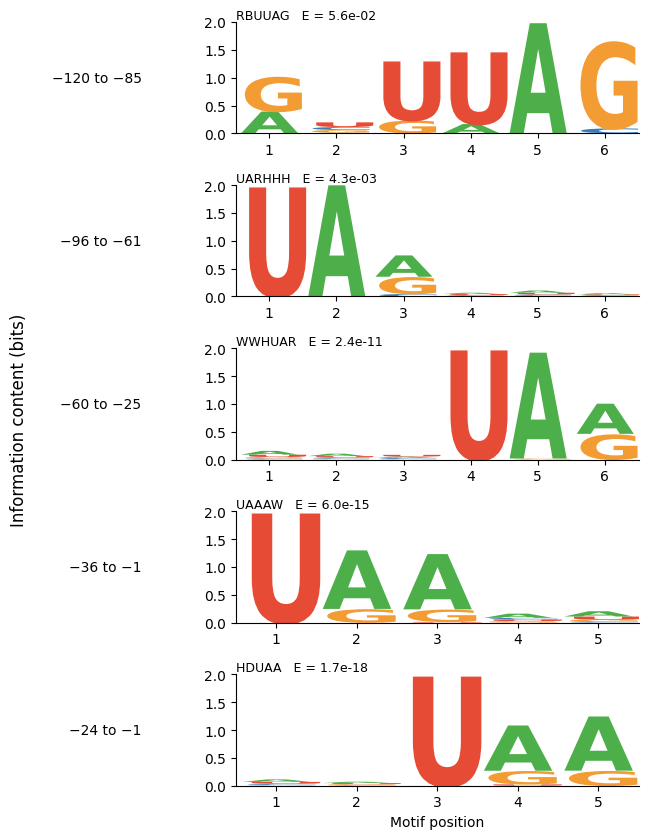

In [10]:
import os,re,numpy as np,pandas as pd,matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties

plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"pdf.fonttype":42,"ps.fonttype":42})

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00"
OUT=BASE+"/motif_figure";os.makedirs(OUT,exist_ok=True)

wins={
"streme_m120_m85":"−120 to −85",
"streme_m96_m61":"−96 to −61",
"streme_m60_m25":"−60 to −25",
"streme_m36_m1":"−36 to −1",
"streme_m24_m1":"−24 to −1"
}

def read_streme(f):
    s=open(f).read().splitlines();out=[]
    for i,x in enumerate(s):
        if not x.startswith("MOTIF "): continue
        name=x.split()[1];cons=name.split("-",1)[-1]
        j=i+1
        while j<len(s) and "letter-probability matrix" not in s[j]: j+=1
        if j==len(s): continue
        h=s[j];w=int(re.search(r"w=\s*(\d+)",h).group(1))
        E=float(re.search(r"E=\s*([\deE.+-]+)",h).group(1))
        n=int(re.search(r"nsites=\s*(\d+)",h).group(1))
        pwm=pd.DataFrame([[float(v) for v in s[j+1+k].split()] for k in range(w)],columns=list("ACGU"))
        out.append({"motif":cons,"E":E,"nsites":n,"pwm":pwm})
    return out

def info_matrix(pwm):
    p=pwm.clip(1e-9,1)
    H=-(p*np.log2(p)).sum(axis=1)
    return p.mul(2-H,axis=0)

colors={"A":"#4DAF4A","C":"#377EB8","G":"#F39C34","U":"#E64B35"}
fp=FontProperties(family="DejaVu Sans",weight="bold")

def draw_logo(ax,mat):
    for x,row in mat.iterrows():
        y=0
        for base,h in sorted(row.items(),key=lambda z:z[1]):
            if h<=0: continue
            tp=TextPath((0,0),base,size=1,prop=fp);bb=tp.get_extents()
            trans=Affine2D().scale(.85/bb.width,h/bb.height).translate(x+.075,y)
            ax.add_patch(PathPatch(tp,transform=trans+ax.transData,color=colors[base],lw=0))
            y+=h
    ax.set_xlim(0,len(mat));ax.set_ylim(0,2)
    ax.set_xticks(np.arange(len(mat))+.5,np.arange(1,len(mat)+1))
    ax.spines[["top","right"]].set_visible(False)

R={}
for folder,label in wins.items():
    f=f"{BASE}/{folder}/streme.txt"
    if os.path.exists(f): R[folder]=read_streme(f)
    else: print("Missing:",f)

summary=[]
for folder,label in wins.items():
    for rank,m in enumerate(sorted(R.get(folder,[]),key=lambda x:x["E"]),1):
        summary.append([label,rank,m["motif"],m["E"],m["nsites"]])
summary=pd.DataFrame(summary,columns=["Region","Rank","Motif","E-value","Sites"])
display(summary)
summary.to_csv(f"{OUT}/run00_motif_summary.csv",index=False)

fig,axs=plt.subplots(5,1,figsize=(6.5,8.5))
for ax,(folder,label) in zip(axs,wins.items()):
    m=sorted(R[folder],key=lambda x:x["E"])[0]
    draw_logo(ax,info_matrix(m["pwm"]))
    ax.set_ylabel(label,rotation=0,ha="right",va="center",labelpad=45)
    ax.set_title(f'{m["motif"]}   E = {m["E"]:.1e}',loc="left",fontsize=9,pad=2)
axs[-1].set_xlabel("Motif position")
fig.supylabel("Information content (bits)",x=.01)
plt.tight_layout()
plt.savefig(f"{OUT}/run00_top_motifs.pdf",bbox_inches="tight")
plt.savefig(f"{OUT}/run00_top_motifs.png",dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00
OUT=$BASE/official_logos

mkdir -p $OUT

for R in m120_m85 m96_m61 m60_m25 m36_m1 m24_m1
do
  mkdir -p $OUT/$R
  meme2images -eps $BASE/streme_$R/streme.txt $OUT/$R
done

find $OUT -name "*.eps"

In [ ]:
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module2_upstream_motif_10runs/run00/official_logos

find $BASE -name "*.eps" | while read f
do
  ps2pdf -dEPSCrop "$f" "${f%.eps}.pdf"
done

In [7]:
###做蛋白的ablation###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_v2_ablation/stage2_v2_ep_protein_ablation_v1/evaluate_stage2_enhanced_position_protein_ablation_v1.py \
  --model_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/train_stage2_rnaesm_cnn_tuned_v1.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs \
  --prepared_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/prepared_datasets \
  --dataset_prefix translation_strict_lenmatched \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test \
  --config_name enhanced_position \
  --start_run 0 \
  --n_runs 10 \
  --batch_size 512 \
  --num_workers 2 \
  --threshold 0.5 \
  --do_whole \
  --do_half \
  --do_position \
  --position_stride 1 \
  --window_size 5 \
  --max_half_pos 75 \
  --min_coverage 0.8 \
  --plot_group pos \
  --esm_layout auto \
  --strict_baseline_check \
  --skip_existing

STAGE2 ENHANCED_POSITION PROTEIN ABLATION
device: cuda
subset: fixed test split only
delta definition: full - ablated
ESM2 embedding zeroed; position channels retained
half rule: N=ceil(L/2), C=floor(L/2)
window_size / stride: 5 / 1
N-half centers: 71
C-half centers: 71

RUN 00
  processed batch 1/9
  processed batch 2/9
  processed batch 3/9
  processed batch 4/9
  processed batch 5/9
  processed batch 6/9
  processed batch 7/9
  processed batch 8/9
  processed batch 9/9
baseline reproduction max |delta probability| = 8.317e-08
Full model             | AUROC 0.8078 | AUPR 0.7954 | Acc 0.7331 | F1 0.7510 | MCC 0.4711
Remove protein         | AUROC 0.6010 | AUPR 0.6329 | Acc 0.5000 | F1 0.0000 | MCC 0.0000 | delta AUROC +0.2069 | delta AUPR +0.1625
Remove N-terminal half | AUROC 0.7060 | AUPR 0.7092 | Acc 0.5014 | F1 0.0054 | MCC 0.0369 | delta AUROC +0.1018 | delta AUPR +0.0862
Remove C-terminal half | AUROC 0.7896 | AUPR 0.7828 | Acc 0.6991 | F1 0.6567 | MCC 0.4109 | delta AUROC +0.01

In [8]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_v2_ablation/stage2_v2_ep_protein_ablation_v1/plot_stage2_enhanced_position_protein_ablation_v1.py \
  --protein_ablation_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test \
  --rna_ablation_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_rna_ab_ws9_stride3_test \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test/importance_metrics_v1_paired \
  --min_coverage 0.8 \
  --max_half_pos 75 \
  --dpi 300 \
  --formats png pdf

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test/importance_metrics_v1_paired/Fig_rna_protein_source_importance_paired.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test/importance_metrics_v1_paired/Fig_rna_protein_source_importance_paired.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test/importance_metrics_v1_paired/Fig_full_vs_rna_protein_ablated_performance_paired.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test/importance_metrics_v1_paired/Fig_full_vs_rna_protein_ablated_performance_paired.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_v2_cnn_ep_protein_ab_ws5_stride1_test/importance_metrics_v1_paired/Fig_n_half_vs_c_half

In [44]:
###用stage1的模型预测一下stage2的数据集和JC数据集###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage1_external_eval_stage2_JC_v1/evaluate_stage1_on_stage2_and_JC_v1.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --model_def /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage1_external_eval_stage2_JC_v1/build_model_rnafm_self_attention.py \
  --run_name_prefix rnafm_self_attention_strict \
  --stage1_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --stage1_dataset_prefix translation_strict_lenmatched \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --stage2_dataset_prefix translation_strict_lenmatched \
  --stage2_label_col binary_label \
  --jc_dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl \
  --jc_label_col auto \
  --negative_label ribotricer \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage1_external_eval_stage2_JC \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --num_workers 2 \
  --threshold 0.5 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2 \
  --stage2_full_ensemble

Device: cuda
Loaded Stage2 run00: (29394, 21)
Loaded Stage2 run01: (29394, 21)
Loaded Stage2 run02: (29394, 21)
Loaded Stage2 run03: (29394, 21)
Loaded Stage2 run04: (29394, 21)
Loaded Stage2 run05: (29394, 21)
Loaded Stage2 run06: (29394, 21)
Loaded Stage2 run07: (29394, 21)
Loaded Stage2 run08: (29394, 21)
Loaded Stage2 run09: (29394, 21)
Loaded JC: (10799, 17)
RNA-FM dimension: 640

Loading Stage1 run00: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage1_external_eval_stage2_JC_v1/build_model_rnafm_self_attention.py:74: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.T

In [ ]:
###整理丰明，景晨数据集以及公共的top down, bottom up数据集###

In [9]:
import pandas as pd
from pathlib import Path
dir1 = Path("/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/FM/pd_out")
dir2 = Path("/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/pub")
out_dir = Path("/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results")
out_dir.mkdir(parents=True, exist_ok=True)
def read_sheet(file, sheet):
    tmp = pd.read_excel(file, sheet_name=sheet, header=None, nrows=20)
    header = next((i for i, row in tmp.iterrows() if {"accession", "proteins"} & {str(x).strip().lower() for x in row.dropna()}), None)
    if header is None:
        return None
    df = pd.read_excel(file, sheet_name=sheet, header=header)
    df.columns = df.columns.astype(str).str.strip()
    col = next((c for c in df.columns if c.lower() in ["accession", "proteins"]), None)
    if col is None:
        return None
    df = df.rename(columns={col: "Accession"})
    df["Accession"] = df["Accession"].astype("string").str.strip()
    return df[df["Accession"].str.startswith("IP_", na=False)].copy()
first = []
for file in sorted(dir1.glob("*.xlsx")):
    if file.name.startswith("~$"):
        continue
    for sheet in pd.ExcelFile(file).sheet_names:
        df = read_sheet(file, sheet)
        if df is not None and not df.empty:
            df["Method"] = "first_batch"
            df["Source"] = file.name
            first.append(df)
first_merged = pd.concat(first, ignore_index=True, sort=False)
first_unique = first_merged.drop_duplicates("Accession").sort_values("Accession")
second = []
for file in sorted(dir2.glob("*.xlsx")):
    if file.name.startswith("~$"):
        continue
    for sheet in pd.ExcelFile(file).sheet_names:
        name = " ".join(sheet.lower().split())
        if "bottom up" not in name and "top down" not in name:
            continue
        df = read_sheet(file, sheet)
        if df is not None and not df.empty:
            df["Method"] = "bottom_up" if "bottom up" in name else "top_down"
            df["Source"] = file.name
            second.append(df)
second_merged = pd.concat(second, ignore_index=True, sort=False)
second_unique = second_merged.drop_duplicates("Accession").sort_values("Accession")
all_merged = pd.concat([first_merged, second_merged], ignore_index=True, sort=False)
final_unique = all_merged.drop_duplicates("Accession").sort_values("Accession").reset_index(drop=True)
first_unique.to_csv(out_dir/"01_first_batch_IP_deduplicated.csv", index=False)
second_unique.to_csv(out_dir/"02_topdown_bottomup_IP_deduplicated.csv", index=False)
final_unique.to_csv(out_dir/"03_all_IP_final_deduplicated.csv", index=False)
print("第一批去重：", len(first_unique))
print("第二批去重：", len(second_unique))
print("最终去重：", len(final_unique))
display(final_unique.head())

第一批去重： 47
第二批去重： 846
最终去重： 882


,Accession,# Unique Peptides,# AAs,Sequence,Modifications,Qvality PEP,Qvality q-value,# PSMs,Method,Source,...,Coverage,G0/G1-PSM,S-PSM,G2/M-PSM,Peptides,Unique Peptides,AAs,G0/G1-Protein isoforms,S-Protein isoforms,G2/M-Protein isoforms
0,IP_059482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bottom_up,pr1c00926_si_002.xlsx,...,11.475410,1.0,0.0,0.0,1.0,1.0,61.0,NaN,NaN,NaN
1,IP_060331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,top_down,pr1c00926_si_002.xlsx,...,NaN,NaN,NaN,NaN,NaN,NaN,163.0,5.0,6.0,7.0
2,IP_060900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bottom_up,pr1c00926_si_002.xlsx,...,11.940299,0.0,1.0,0.0,1.0,1.0,67.0,NaN,NaN,NaN
3,IP_061262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,top_down,pr1c00926_si_002.xlsx,...,NaN,NaN,NaN,NaN,NaN,NaN,99.0,0.0,1.0,0.0
4,IP_063039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,top_down,pr1c00926_si_002.xlsx,...,NaN,NaN,NaN,NaN,NaN,NaN,138.0,0.0,1.0,0.0


In [10]:
###去重stage2中用过的小蛋白###
import pandas as pd
from pathlib import Path
table_file = Path("/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/03_all_IP_final_deduplicated.csv")
stage2_dir = Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs")
out_dir = table_file.parent
df = pd.read_csv(table_file)
stage2_acc = set()
for run in range(10):
    x = pd.read_pickle(stage2_dir/f"translation_strict_lenmatched_run{run:02d}.pkl")
    col = next((c for c in ["protein_accession", "Accession", "accession"] if c in x.columns), None)
    if col is None:
        raise ValueError(f"run{run:02d}未找到蛋白编号列：{x.columns.tolist()}")
    stage2_acc.update(x[col].dropna().astype(str).str.strip())
df["Accession"] = df["Accession"].astype(str).str.strip()
removed = df[df["Accession"].isin(stage2_acc)].copy()
filtered = df[~df["Accession"].isin(stage2_acc)].drop_duplicates("Accession").reset_index(drop=True)
filtered.to_csv(out_dir/"04_all_IP_exclude_stage2_deduplicated.csv", index=False)
removed.to_csv(out_dir/"04_IP_removed_due_to_stage2.csv", index=False)
print("原始蛋白数：", len(df))
print("Stage2数据集涉及蛋白数：", len(stage2_acc))
print("排除的重叠蛋白数：", len(removed))
print("最终保留蛋白数：", len(filtered))
display(filtered.head())

原始蛋白数： 882
Stage2数据集涉及蛋白数： 47455
排除的重叠蛋白数： 29
最终保留蛋白数： 853


,Accession,# Unique Peptides,# AAs,Sequence,Modifications,Qvality PEP,Qvality q-value,# PSMs,Method,Source,...,Coverage,G0/G1-PSM,S-PSM,G2/M-PSM,Peptides,Unique Peptides,AAs,G0/G1-Protein isoforms,S-Protein isoforms,G2/M-Protein isoforms
0,IP_059482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bottom_up,pr1c00926_si_002.xlsx,...,11.475410,1.0,0.0,0.0,1.0,1.0,61.0,NaN,NaN,NaN
1,IP_060331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,top_down,pr1c00926_si_002.xlsx,...,NaN,NaN,NaN,NaN,NaN,NaN,163.0,5.0,6.0,7.0
2,IP_060900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bottom_up,pr1c00926_si_002.xlsx,...,11.940299,0.0,1.0,0.0,1.0,1.0,67.0,NaN,NaN,NaN
3,IP_061262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,top_down,pr1c00926_si_002.xlsx,...,NaN,NaN,NaN,NaN,NaN,NaN,99.0,0.0,1.0,0.0
4,IP_063039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,top_down,pr1c00926_si_002.xlsx,...,NaN,NaN,NaN,NaN,NaN,NaN,138.0,0.0,1.0,0.0


In [ ]:
###丰明，景晨，cellcycle的数据作为测试集###

In [11]:
####提取想要的分类信息，并提取序列信息####
import pandas as pd
import numpy as np

# 1) 读取 OpenProt 表
openprot_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv"
df = pd.read_csv(openprot_file, sep="\t", low_memory=False)
print(df.shape)
# 2) 基础清洗
df["protein type"] = df["protein type"].fillna("Unknown")
df["MS score"] = pd.to_numeric(df["MS score"], errors="coerce").fillna(0)
print(df.shape)
df["TE Translation Event score"] = pd.to_numeric(df["TE Translation Event score"], errors="coerce").fillna(0)

# 3) 只保留 AltProt
alt = df[df["protein type"] == "AltProt"].copy()

# 4) 定义你关心的 4 类
def assign_group(row):
    ms = row["MS score"]
    te = row["TE Translation Event score"]
    if ms == 0 and te >= 2:
        return "MS-|Ribo++"
    elif ms == 1 and te >= 2:
        return "MS+|Ribo++"
    elif ms >= 2 and te >= 2:
        return "MS++|Ribo++"
    elif ms >= 2 and te ==1:
        return "MS++|Ribo+"
    elif ms == 1 and te ==1:
        return "MS+|Ribo+"
    elif ms == 0 and te ==1:
        return "MS-|Ribo+"
    elif ms == 0 and te ==0:
        return "MS-|Ribo-"
    elif ms == 1 and te ==0:
        return "MS+|Ribo-"
    elif ms >= 2 and te ==0:
        return "MS++|Ribo-"
    else:
        return "nan"

alt["group"] = alt.apply(assign_group, axis=1)

# 5) 只保留这 4 类
alt4 = alt[alt["group"].notna()].copy()

# 6) 看结果
print("原始表大小:", df.shape)
print("AltProt 数量:", alt.shape)
print("4 类 AltProt 数量:", alt4.shape)
print("\n各组数量：")
print(alt4["group"].value_counts(dropna=False))

# 7) 看后面提序列最关键的列是否存在
need_cols = [
    "protein accession",
    "protein accession (others)",
    "gene symbol",
    "transcript accession",
    "start transcript coordinates",
    "stop transcript coordinates",
    "protein length (a.a.)",
    "MS score",
    "TE Translation Event score",
    "group"
]

print("\n关键列是否都在：")
for c in need_cols:
    print(c, "->", c in alt4.columns)

# 8) 展示前几行
display(alt4[need_cols].head())

(2572995, 22)
(2572995, 22)
原始表大小: (2572995, 22)
AltProt 数量: (2140853, 23)
4 类 AltProt 数量: (2140853, 23)

各组数量：
group
MS-|Ribo-      904864
MS+|Ribo-      634568
MS++|Ribo-     521655
MS-|Ribo+       16898
MS-|Ribo++      14521
MS++|Ribo+      12984
MS+|Ribo+       12355
MS++|Ribo++     11654
MS+|Ribo++      11354
Name: count, dtype: int64

关键列是否都在：
protein accession -> True
protein accession (others) -> True
gene symbol -> True
transcript accession -> True
start transcript coordinates -> True
stop transcript coordinates -> True
protein length (a.a.) -> True
MS score -> True
TE Translation Event score -> True
group -> True


,protein accession,protein accession (others),gene symbol,transcript accession,start transcript coordinates,stop transcript coordinates,protein length (a.a.),MS score,TE Translation Event score,group
1,IP_057216,"IP_057216,IP_057216",OR4F5,NM_001005484.2,480.0,621.0,46,0,0,MS-|Ribo-
2,IP_057216,"IP_057216,IP_057216",OR4F5,ENST00000641515.2,480.0,621.0,46,0,0,MS-|Ribo-
13,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F29,NM_001005221.2,248.0,350.0,33,2,0,MS++|Ribo-
14,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_024449992.2,2743.0,2845.0,33,2,0,MS++|Ribo-
15,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_017002410.2,2755.0,2857.0,33,2,0,MS++|Ribo-


In [12]:
ip_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/04_all_IP_exclude_stage2_deduplicated.csv"
out_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/alt4_matched_IP.csv"

ids = pd.read_csv(ip_file)["Accession"].astype(str).str.strip().unique()
result = alt4[
    alt4["protein accession"].astype(str).str.strip().isin(ids)
].copy()

result.to_csv(out_file, index=False, encoding="utf-8-sig")

print("输入IP数：", len(ids))
print("匹配IP数：", result["protein accession"].nunique())
print("提取记录数：", len(result))
print("未匹配IP数：", len(set(ids) - set(result["protein accession"].astype(str).str.strip())))
display(result.head())

输入IP数： 853
匹配IP数： 711
提取记录数： 2056
未匹配IP数： 142


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains,group
15217,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,mRNA,3'UTR,2620.0,2806.0,1,0,-,-,0,MS+|Ribo-
15218,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,3.0,ARHGEF19,1,16198370.0,...,mRNA,3'UTR,2694.0,2880.0,1,0,-,-,0,MS+|Ribo-
15219,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,mRNA,3'UTR,2620.0,2806.0,1,0,-,-,0,MS+|Ribo-
15220,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,misc_RNA,-,1333.0,1519.0,1,0,-,-,0,MS+|Ribo-
23076,IP_060331,IP_060331,AltProt,163,17.80,8.01,1.0,PPIAP34,1,22322839.0,...,misc_RNA,-,1.0,493.0,14,0,+,-,8,MS++|Ribo-


In [13]:
#合并大表alt4和小标2pep的alt4_2pep#
alt4_combined=result

###去重复###
# 1) 只保留 Ensembl transcript
alt4_ens = alt4_combined.copy()
alt4_ens["transcript accession"] = alt4_ens["transcript accession"].astype(str).str.strip()
alt4_ens = alt4_ens[alt4_ens["transcript accession"].str.startswith("ENST", na=False)].copy()

print("只保留 ENST 后行数:", alt4_ens.shape[0])
print("唯一 protein accession 数:", alt4_ens["protein accession"].nunique())
display(alt4_ens[["protein accession", "transcript accession"]].head(10))
alt4_ens["tx_base"] = alt4_ens["transcript accession"].str.split(".").str[0]

##读取cDNA的fasta文件，引入transcript长度，然后去重##
from Bio import SeqIO
import pandas as pd

#cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.all.fa"
cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.ncrna.merge.fa"#这个是合并了cdna和ncrna之后的fa文件


# 1) 读取 fasta
tx_seq_dict = {}
tx_len_dict = {}

for record in SeqIO.parse(cdna_fasta, "fasta"):
    tx_id = record.id.split("|")[0]   # 保留完整 ENSTxxxx.x
    seq = str(record.seq).upper().replace("U", "T")
    
    tx_seq_dict[tx_id] = seq
    tx_len_dict[tx_id] = len(seq)

print("fasta中 transcript 数:", len(tx_seq_dict))

# 2) 直接用完整 accession 匹配
alt4_ens["transcript_length"] = alt4_ens["transcript accession"].map(tx_len_dict)

# 3) 检查匹配情况
print("\ntranscript_length 缺失情况：")
print(alt4_ens["transcript_length"].isna().value_counts())

print("\n匹配成功比例：", alt4_ens["transcript_length"].notna().mean())

# 4) 看前几行
display(
    alt4_ens[[
        "protein accession",
        "transcript accession",
        "transcript_length"
    ]].head(10)
)

# 5) 看没匹配到的（理论上应该接近 0）
not_found = alt4_ens[alt4_ens["transcript_length"].isna()]
display(not_found[["protein accession", "transcript accession"]].head(10))

alt4_ens_found=alt4_ens[alt4_ens['transcript_length'].notna()]
display(alt4_ens_found.head(10))

只保留 ENST 后行数: 1115
唯一 protein accession 数: 711


,protein accession,transcript accession
15219,IP_059482,ENST00000270747.8
15220,IP_059482,ENST00000478117.5
23076,IP_060331,ENST00000487348.1
26978,IP_060900,ENST00000374296.4
26979,IP_060900,ENST00000675840.1
28845,IP_061262,ENST00000374024.4
43037,IP_063453,ENST00000372583.6
43038,IP_063453,ENST00000460604.1
43261,IP_063470,ENST00000372571.5
43262,IP_063470,ENST00000372572.5


fasta中 transcript 数: 267165

transcript_length 缺失情况：
transcript_length
False    1105
True       10
Name: count, dtype: int64

匹配成功比例： 0.9910313901345291


,protein accession,transcript accession,transcript_length
15219,IP_059482,ENST00000270747.8,3322.0
15220,IP_059482,ENST00000478117.5,2035.0
23076,IP_060331,ENST00000487348.1,492.0
26978,IP_060900,ENST00000374296.4,3023.0
26979,IP_060900,ENST00000675840.1,2685.0
28845,IP_061262,ENST00000374024.4,2137.0
43037,IP_063453,ENST00000372583.6,12617.0
43038,IP_063453,ENST00000460604.1,2369.0
43261,IP_063470,ENST00000372571.5,4468.0
43262,IP_063470,ENST00000372572.5,5352.0


,protein accession,transcript accession
1832209,IP_580466,ENST00000623178.1
1851132,IP_590783,ENST00000623222.1
1862308,IP_596925,ENST00000624252.1
2003947,IP_671739,ENST00000624418.1
2058496,IP_701409,ENST00000623938.1
2067490,IP_706467,ENST00000624661.1
2072342,IP_708748,ENST00000624554.1
2097382,IP_723539,ENST00000623140.1
2193954,IP_773666,ENST00000622964.1
2218780,IP_789154,ENST00000624563.1


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains,group,tx_base,transcript_length
15219,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,2620.0,2806.0,1,0,-,-,0,MS+|Ribo-,ENST00000270747,3322.0
15220,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,1333.0,1519.0,1,0,-,-,0,MS+|Ribo-,ENST00000478117,2035.0
23076,IP_060331,IP_060331,AltProt,163,17.80,8.01,1.0,PPIAP34,1,22322839.0,...,1.0,493.0,14,0,+,-,8,MS++|Ribo-,ENST00000487348,492.0
26978,IP_060900,"IP_060900,IP_060900,IP_060900,IP_060900,IP_060...",AltProt,67,8.18,10.70,2.0,PAQR7,1,25861850.0,...,2453.0,2657.0,3,0,-,-,7,MS++|Ribo-,ENST00000374296,3023.0
26979,IP_060900,"IP_060900,IP_060900,IP_060900,IP_060900,IP_060...",AltProt,67,8.18,10.70,3.0,PAQR7,1,25861850.0,...,2115.0,2319.0,3,0,-,-,7,MS++|Ribo-,ENST00000675840,2685.0
28845,IP_061262,"IP_061262,IP_061262",AltProt,99,10.67,7.44,3.0,GPR3,1,27394837.0,...,1161.0,1461.0,0,0,-,-,1,MS-|Ribo-,ENST00000374024,2137.0
43037,IP_063453,"IP_063453,IP_063453,IP_063453",AltProt,166,17.53,12.61,2.0,HIVEP3,1,41511183.0,...,7298.0,7799.0,4,0,-,-,2,MS++|Ribo-,ENST00000372583,12617.0
43038,IP_063453,"IP_063453,IP_063453,IP_063453",AltProt,166,17.53,12.61,3.0,HIVEP3,1,41511183.0,...,915.0,1416.0,4,0,-,-,2,MS++|Ribo-,ENST00000460604,2369.0
43261,IP_063470,"IP_063470,IP_063470,IP_063470,IP_063470,IP_063...",AltProt,95,10.28,9.08,1.0,FOXJ3,1,42178540.0,...,2179.0,2467.0,1,0,-,-,8,MS+|Ribo-,ENST00000372571,4468.0
43262,IP_063470,"IP_063470,IP_063470,IP_063470,IP_063470,IP_063...",AltProt,95,10.28,9.08,3.0,FOXJ3,1,42178540.0,...,3063.0,3351.0,1,0,-,-,8,MS+|Ribo-,ENST00000372572,5352.0


In [14]:
# 先看去重前
print("去重前行数:", alt4_ens_found.shape[0])
print("唯一 protein accession 数:", alt4_ens_found["protein accession"].nunique())

# 按 transcript_length 从大到小排序，再按 protein accession 去重
alt4_ens_found_dedup = (
    alt4_ens_found
    .sort_values(["protein accession", "transcript_length"], ascending=[True, False])
    .drop_duplicates(subset=["protein accession"], keep="first")
    .copy()
)

# 看去重后
print("去重后行数:", alt4_ens_found_dedup.shape[0])

# 看前几行
display(
    alt4_ens_found_dedup[[
        "protein accession",
        "transcript accession",
        "transcript_length",
        "group"
    ]].head(10)
)
print(alt4_ens_found_dedup['group'].value_counts())

去重前行数: 1105
唯一 protein accession 数: 701
去重后行数: 701


,protein accession,transcript accession,transcript_length,group
15219,IP_059482,ENST00000270747.8,3322.0,MS+|Ribo-
23076,IP_060331,ENST00000487348.1,492.0,MS++|Ribo-
26978,IP_060900,ENST00000374296.4,3023.0,MS++|Ribo-
28845,IP_061262,ENST00000374024.4,2137.0,MS-|Ribo-
43037,IP_063453,ENST00000372583.6,12617.0,MS++|Ribo-
43262,IP_063470,ENST00000372572.5,5352.0,MS+|Ribo-
51353,IP_064519,ENST00000606738.3,7524.0,MS++|Ribo-
92264,IP_070032,ENST00000271640.9,4437.0,MS+|Ribo-
98357,IP_071058,ENST00000368476.4,5857.0,MS-|Ribo-
113203,IP_073342,ENST00000465089.2,11321.0,MS++|Ribo-


group
MS++|Ribo-     365
MS-|Ribo-      147
MS+|Ribo-      143
MS++|Ribo+      22
MS++|Ribo++     12
MS+|Ribo+        5
MS-|Ribo+        3
MS-|Ribo++       2
MS+|Ribo++       2
Name: count, dtype: int64


In [15]:
# 先复制一份，避免改原表
ml_df = alt4_ens_found_dedup.copy()

# 1) 坐标转成数值
ml_df["start transcript coordinates"] = pd.to_numeric(
    ml_df["start transcript coordinates"], errors="coerce"
)
ml_df["stop transcript coordinates"] = pd.to_numeric(
    ml_df["stop transcript coordinates"], errors="coerce"
)

# 2) 提取序列函数
#UP_LEN = 50
#DOWN_LEN = 50

UP_LEN = 450
DOWN_LEN = 450

def extract_tx_seqs(row):
    tx_id = row["transcript accession"]
    start = row["start transcript coordinates"]
    stop = row["stop transcript coordinates"]
    
    # transcript 序列字典：你前面已经建立过 tx_seq_dict
    tx_seq = tx_seq_dict.get(tx_id, None)
    
    if tx_seq is None or pd.isna(start) or pd.isna(stop):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    # transcript 坐标通常按 1-based, inclusive 处理
    s = int(min(start, stop))
    e = int(max(start, stop))
    
    # 转成 python 切片
    s0 = s - 1
    e0 = e-1
    
    # 边界检查
    if s0 < 0 or e0 > len(tx_seq):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    orf_seq = tx_seq[s0:e0]
    up_seq = tx_seq[max(0, s0 - UP_LEN): s0]
    down_seq = tx_seq[e0: min(len(tx_seq), e0 + DOWN_LEN)]
    
    return pd.Series({
        "orf_rna_seq": orf_seq,
        "upstream_50nt": up_seq,
        "downstream_50nt": down_seq,
        "orf_nt_len": len(orf_seq),
        "seq_ok": 1
    })

# 3) 批量提取
seq_df = ml_df.apply(extract_tx_seqs, axis=1)
ml_df = pd.concat([ml_df, seq_df], axis=1)

# 4) 看结果
print("成功提取比例：", ml_df["seq_ok"].mean())
print("\nseq_ok 计数：")
print(ml_df["seq_ok"].value_counts(dropna=False))

display(
    ml_df[[
        "protein accession",
        "transcript accession",
        "start transcript coordinates",
        "stop transcript coordinates",
        "transcript_length",
        "orf_nt_len",
        "orf_rna_seq",
        "upstream_50nt",
        "downstream_50nt",
        "group"
    ]].head(10)
)

成功提取比例： 1.0

seq_ok 计数：
seq_ok
1    701
Name: count, dtype: int64


,protein accession,transcript accession,start transcript coordinates,stop transcript coordinates,transcript_length,orf_nt_len,orf_rna_seq,upstream_50nt,downstream_50nt,group
15219,IP_059482,ENST00000270747.8,2620.0,2806.0,3322.0,186,ATGCCTGGCTCCTGGATGGTCCTGGAGGGGCCTGCAGTGTCTCCAT...,CCCGGCCACGTGTTCCTCCTCCAGCTCCTCCACGGGCAGCACATGA...,TTTCTTCCTCTGACATGGGGACCATAACAGGTGATCACTGATACCT...,MS+|Ribo-
23076,IP_060331,ENST00000487348.1,1.0,493.0,492.0,492,ATGGTCAACCCCACTGTGTTCATTGATGGTGAGTCCTTGGGCCACG...,,,MS++|Ribo-
26978,IP_060900,ENST00000374296.4,2453.0,2657.0,3023.0,204,ATGACAAAGGCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGAGG...,GGGGGTCAGCTTGGTGAGGATTGGGGCTTCTAGATTGTCTAGGCAG...,TAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGGTCTTGAACTCCT...,MS++|Ribo-
28845,IP_061262,ENST00000374024.4,1161.0,1461.0,2137.0,300,ATGTTAGGCTCTCCAGGGCTTCTTTCCAAACCCCCAGCTCCACACC...,TTCTGGCCATTGCCTTCTTCATGGTGTTTGGCATCATGCTGCAGCT...,GCTAAAGAGTCAGAGAGATTAGTCACATAGTTGCCTAAATAGGAGA...,MS-|Ribo-
43037,IP_063453,ENST00000372583.6,7298.0,7799.0,12617.0,501,ATGCTCCCCGGCCCGAGAACCACAGGCCTCAGCCCCAAGCCCACCT...,GTTTTCGGACCTGGAGGACTCGGACTCAGACTCAGACCTGGACGAA...,CTTCCACGGCCACATCCTGGCCCGGACAGAGGAGAACATCTTCAGC...,MS++|Ribo-
43262,IP_063470,ENST00000372572.5,3063.0,3351.0,5352.0,288,ATGTGTCTGAAAGCACAGAACTATTATTATTTTTTTCTTTTTTTGA...,AGTTTTTATTCCTTGTTAGGCTATTTTCTGCAGGATGCTTTTAACT...,AGTGCTGGGATTACAGACATGAGCCACTGCGCCTGGCCCAGCGTTA...,MS+|Ribo-
51353,IP_064519,ENST00000606738.3,3251.0,3512.0,7524.0,261,ATGTGGCCCCAGATCAGTGTGATGCAAAACAATTCCTGCCTCCTGT...,GGTGGGATACTGGTGCTGAGGAAAGCAGTCCCCACCCCACAGAACA...,GAGGTGGGCACAGCTGTGGGGCACCTGGGGAGGCACAGCAGCCAAG...,MS++|Ribo-
92264,IP_070032,ENST00000271640.9,936.0,1035.0,4437.0,99,ATGATTACCACCCTCCTGCTGACAAGCTGTATGTGGGCAGTCGGGT...,TCTACTCCAAGCTGGGACTACAATACCGGGACAGTAGCTCTGAGGA...,CTGAGACACCAAACGTCAAAAACAAGCTCAGGTTTCTCATTTTCTT...,MS+|Ribo-
98357,IP_071058,ENST00000368476.4,2809.0,2974.0,5857.0,165,ATGTTAGCTTTAAGCCAACCCAGCCTCTTTGTCCACAGCAGAGCTG...,CCCTGGGGGAGGCTTCCAGCTCAGTCCCACAGCCCCTTGCTTCTAA...,AGCAGAACTTGGGAAGGACAGGGCTGCTGCTGCCAGCGACACCTCA...,MS-|Ribo-
113203,IP_073342,ENST00000465089.2,8089.0,8506.0,11321.0,417,ATGTTAACAGGCAATCCTTCTCTGTTTCTCTTATTACTCTCACTAC...,GATCTCCCAGCAATCGCATCCCGGCTGACCCTGTGCCCCAGTTGGG...,GCATGGTGATGAATGCATCAGCAAGGAATAGAAAGTTCTTATCGTG...,MS++|Ribo-


In [16]:
out_csv='/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/test_table_FMJCpub.csv.gz'
ml_df.to_csv(out_csv, index=False, compression="gzip")

In [17]:
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/test_table_FMJCpub.csv.gz')
df_gencode_pos['sample_id']=df_gencode_pos['protein accession']
df_gencode_pos['protein_len_aa']=df_gencode_pos['protein length (a.a.)']
df_gencode_pos['orf_seq']=df_gencode_pos['orf_rna_seq']
df_gencode_pos['upstream_seq_50nt']=df_gencode_pos['upstream_50nt']
df_gencode_pos['downstream_seq_50nt']=df_gencode_pos['downstream_50nt']
df_gencode_pos['label_raw']=df_gencode_pos['group']
df_gencode_pos['label_id']=9
display(df_gencode_pos.head())
groups = ["MS++|Ribo-", "MS+|Ribo-", "MS-|Ribo-"]
df_gencode_pos_part1 = df_gencode_pos[df_gencode_pos["group"].isin(groups)].copy()
display(df_gencode_pos_part1.head())

,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,downstream_50nt,orf_nt_len,seq_ok,sample_id,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,label_raw,label_id
0,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,TTTCTTCCTCTGACATGGGGACCATAACAGGTGATCACTGATACCT...,186,1,IP_059482,61,ATGCCTGGCTCCTGGATGGTCCTGGAGGGGCCTGCAGTGTCTCCAT...,CCCGGCCACGTGTTCCTCCTCCAGCTCCTCCACGGGCAGCACATGA...,TTTCTTCCTCTGACATGGGGACCATAACAGGTGATCACTGATACCT...,MS+|Ribo-,9
1,IP_060331,IP_060331,AltProt,163,17.80,8.01,1.0,PPIAP34,1,22322839.0,...,NaN,492,1,IP_060331,163,ATGGTCAACCCCACTGTGTTCATTGATGGTGAGTCCTTGGGCCACG...,NaN,NaN,MS++|Ribo-,9
2,IP_060900,"IP_060900,IP_060900,IP_060900,IP_060900,IP_060...",AltProt,67,8.18,10.70,2.0,PAQR7,1,25861850.0,...,TAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGGTCTTGAACTCCT...,204,1,IP_060900,67,ATGACAAAGGCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGAGG...,GGGGGTCAGCTTGGTGAGGATTGGGGCTTCTAGATTGTCTAGGCAG...,TAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGGTCTTGAACTCCT...,MS++|Ribo-,9
3,IP_061262,"IP_061262,IP_061262",AltProt,99,10.67,7.44,3.0,GPR3,1,27394837.0,...,GCTAAAGAGTCAGAGAGATTAGTCACATAGTTGCCTAAATAGGAGA...,300,1,IP_061262,99,ATGTTAGGCTCTCCAGGGCTTCTTTCCAAACCCCCAGCTCCACACC...,TTCTGGCCATTGCCTTCTTCATGGTGTTTGGCATCATGCTGCAGCT...,GCTAAAGAGTCAGAGAGATTAGTCACATAGTTGCCTAAATAGGAGA...,MS-|Ribo-,9
4,IP_063453,"IP_063453,IP_063453,IP_063453",AltProt,166,17.53,12.61,2.0,HIVEP3,1,41511183.0,...,CTTCCACGGCCACATCCTGGCCCGGACAGAGGAGAACATCTTCAGC...,501,1,IP_063453,166,ATGCTCCCCGGCCCGAGAACCACAGGCCTCAGCCCCAAGCCCACCT...,GTTTTCGGACCTGGAGGACTCGGACTCAGACTCAGACCTGGACGAA...,CTTCCACGGCCACATCCTGGCCCGGACAGAGGAGAACATCTTCAGC...,MS++|Ribo-,9


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,downstream_50nt,orf_nt_len,seq_ok,sample_id,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,label_raw,label_id
0,IP_059482,"IP_059482,IP_059482,IP_059482,IP_059482",AltProt,61,6.51,8.23,1.0,ARHGEF19,1,16198370.0,...,TTTCTTCCTCTGACATGGGGACCATAACAGGTGATCACTGATACCT...,186,1,IP_059482,61,ATGCCTGGCTCCTGGATGGTCCTGGAGGGGCCTGCAGTGTCTCCAT...,CCCGGCCACGTGTTCCTCCTCCAGCTCCTCCACGGGCAGCACATGA...,TTTCTTCCTCTGACATGGGGACCATAACAGGTGATCACTGATACCT...,MS+|Ribo-,9
1,IP_060331,IP_060331,AltProt,163,17.80,8.01,1.0,PPIAP34,1,22322839.0,...,NaN,492,1,IP_060331,163,ATGGTCAACCCCACTGTGTTCATTGATGGTGAGTCCTTGGGCCACG...,NaN,NaN,MS++|Ribo-,9
2,IP_060900,"IP_060900,IP_060900,IP_060900,IP_060900,IP_060...",AltProt,67,8.18,10.70,2.0,PAQR7,1,25861850.0,...,TAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGGTCTTGAACTCCT...,204,1,IP_060900,67,ATGACAAAGGCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGAGG...,GGGGGTCAGCTTGGTGAGGATTGGGGCTTCTAGATTGTCTAGGCAG...,TAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGGTCTTGAACTCCT...,MS++|Ribo-,9
3,IP_061262,"IP_061262,IP_061262",AltProt,99,10.67,7.44,3.0,GPR3,1,27394837.0,...,GCTAAAGAGTCAGAGAGATTAGTCACATAGTTGCCTAAATAGGAGA...,300,1,IP_061262,99,ATGTTAGGCTCTCCAGGGCTTCTTTCCAAACCCCCAGCTCCACACC...,TTCTGGCCATTGCCTTCTTCATGGTGTTTGGCATCATGCTGCAGCT...,GCTAAAGAGTCAGAGAGATTAGTCACATAGTTGCCTAAATAGGAGA...,MS-|Ribo-,9
4,IP_063453,"IP_063453,IP_063453,IP_063453",AltProt,166,17.53,12.61,2.0,HIVEP3,1,41511183.0,...,CTTCCACGGCCACATCCTGGCCCGGACAGAGGAGAACATCTTCAGC...,501,1,IP_063453,166,ATGCTCCCCGGCCCGAGAACCACAGGCCTCAGCCCCAAGCCCACCT...,GTTTTCGGACCTGGAGGACTCGGACTCAGACTCAGACCTGGACGAA...,CTTCCACGGCCACATCCTGGCCCGGACAGAGGAGAACATCTTCAGC...,MS++|Ribo-,9


In [18]:
import os
import pandas as pd

df_gencode_neg1w=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/ribotricer_clean_unused_sample10000.csv.gz')
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/test_table_FMJCpub.csv.gz')
print(df_gencode_pos['group'].value_counts())
print(df_gencode_neg1w['label_id'].value_counts())
print(min(df_gencode_neg1w['protein_len_aa']),max(df_gencode_neg1w['protein_len_aa']))
print(min(df_gencode_pos['protein length (a.a.)']),max(df_gencode_pos['protein length (a.a.)']))
df_gencode_pos['sample_id']=df_gencode_pos['protein accession']
df_gencode_pos['protein_len_aa']=df_gencode_pos['protein length (a.a.)']
df_gencode_pos['orf_seq']=df_gencode_pos['orf_rna_seq']
df_gencode_pos['upstream_seq_50nt']=df_gencode_pos['upstream_50nt']
df_gencode_pos['downstream_seq_50nt']=df_gencode_pos['downstream_50nt']
df_gencode_pos['label_raw']=df_gencode_pos['group']
df_gencode_pos['label_id']=9
groups = ["MS++|Ribo-", "MS+|Ribo-", "MS-|Ribo-"]
df_gencode_pos_part1 = df_gencode_pos[df_gencode_pos["group"].isin(groups)].copy()

df_gencode_pos=df_gencode_pos_part1

cols = [
    "sample_id", "protein_accession", "transcript_accession",
    "protein_len_aa", "orf_seq", "upstream_seq_50nt", "downstream_seq_50nt",
    "orf_nt_len", "label_raw", "protein_len_a", "label_id"
]

out_csv = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_pos_ribotricer_neg_merged.csv.gz"

# 去重复列
df_gencode_pos = df_gencode_pos.loc[:, ~df_gencode_pos.columns.duplicated()].copy()
df_gencode_neg1w = df_gencode_neg1w.loc[:, ~df_gencode_neg1w.columns.duplicated()].copy()

df_gencode_neg1w = df_gencode_neg1w.sample(
    n=len(df_gencode_pos),
    random_state=42
).reset_index(drop=True)

# 统一 protein_len_aa / protein_len_a
for df in [df_gencode_pos, df_gencode_neg1w]:
    if "protein_len_aa" not in df.columns and "protein_len_a" in df.columns:
        df["protein_len_aa"] = df["protein_len_a"]
    if "protein_len_a" not in df.columns and "protein_len_aa" in df.columns:
        df["protein_len_a"] = df["protein_len_aa"]
    if "orf_nt_len" not in df.columns:
        df["orf_nt_len"] = df["orf_seq"].astype(str).str.len()
        
df_merge = pd.concat(
    [
        df_gencode_pos.reindex(columns=cols),
        df_gencode_neg1w.reindex(columns=cols)
    ],
    axis=0,
    ignore_index=True
)
# 去重并保存
df_merge = df_merge.drop_duplicates("sample_id").reset_index(drop=True)

os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df_merge.to_csv(out_csv, index=False, compression="gzip")

print("保存成功:", out_csv)
print("合并后 shape:", df_merge.shape)
print(df_merge["label_raw"].value_counts())
display(df_merge.head())

group
MS++|Ribo-     365
MS-|Ribo-      147
MS+|Ribo-      143
MS++|Ribo+      22
MS++|Ribo++     12
MS+|Ribo+        5
MS-|Ribo+        3
MS-|Ribo++       2
MS+|Ribo++       2
Name: count, dtype: int64
label_id
7    10000
Name: count, dtype: int64
30 150
29 1261
保存成功: /disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_pos_ribotricer_neg_merged.csv.gz
合并后 shape: (1310, 11)
label_raw
ribotricer    655
MS++|Ribo-    365
MS-|Ribo-     147
MS+|Ribo-     143
Name: count, dtype: int64


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
0,IP_059482,NaN,NaN,61,ATGCCTGGCTCCTGGATGGTCCTGGAGGGGCCTGCAGTGTCTCCAT...,CCCGGCCACGTGTTCCTCCTCCAGCTCCTCCACGGGCAGCACATGA...,TTTCTTCCTCTGACATGGGGACCATAACAGGTGATCACTGATACCT...,186,MS+|Ribo-,61,9
1,IP_060331,NaN,NaN,163,ATGGTCAACCCCACTGTGTTCATTGATGGTGAGTCCTTGGGCCACG...,NaN,NaN,492,MS++|Ribo-,163,9
2,IP_060900,NaN,NaN,67,ATGACAAAGGCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGAGG...,GGGGGTCAGCTTGGTGAGGATTGGGGCTTCTAGATTGTCTAGGCAG...,TAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGGTCTTGAACTCCT...,204,MS++|Ribo-,67,9
3,IP_061262,NaN,NaN,99,ATGTTAGGCTCTCCAGGGCTTCTTTCCAAACCCCCAGCTCCACACC...,TTCTGGCCATTGCCTTCTTCATGGTGTTTGGCATCATGCTGCAGCT...,GCTAAAGAGTCAGAGAGATTAGTCACATAGTTGCCTAAATAGGAGA...,300,MS-|Ribo-,99,9
4,IP_063453,NaN,NaN,166,ATGCTCCCCGGCCCGAGAACCACAGGCCTCAGCCCCAAGCCCACCT...,GTTTTCGGACCTGGAGGACTCGGACTCAGACTCAGACCTGGACGAA...,CTTCCACGGCCACATCCTGGCCCGGACAGAGGAGAACATCTTCAGC...,501,MS++|Ribo-,166,9


In [20]:
#提RNA特征#
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_rnafm_token_nt450_ribotricer_openprot_transcript_5to3_v2.py \
  --input_table /disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_pos_ribotricer_neg_merged.csv.gz \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_FMJCpub_ribo \
  --local_model_dir /disk3/hejp/00_thesis/4_predict_translation/model/rnafm \
  --model_name rna-fm \
  --run_region all \
  --upstream_col upstream_seq_50nt \
  --orf_col orf_seq \
  --downstream_col downstream_seq_50nt \
  --id_col sample_id \
  --label_col label_raw \
  --min_aa 0 \
  --max_aa 1500 \
  --dna_source coding \
  --batch_size 1 \
  --too_long skip \
  --device cuda

[INFO] RNA-FM token-level feature extraction
[INFO] input_table: /disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_pos_ribotricer_neg_merged.csv.gz
[INFO] out_dir: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_FMJCpub_ribo
[INFO] local_model_dir: /disk3/hejp/00_thesis/4_predict_translation/model/rnafm
[INFO] model_name: rna-fm
[INFO] run_region: all
[INFO] dna_source: coding
[INFO] device: cuda

[INFO] Loading input table...
[INFO] Input shape: (1310, 11)
[INFO] Columns: ['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id']
[INFO] Infer aa length from ORF sequence

[INFO] Keep microproteins: 0 <= aa_len <= 1500
[INFO] Remaining samples: 1310
[INFO] Filtered rows saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_FMJCpub_ribo/rn

In [21]:
###提取蛋白特征###
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_esm2_token_embedding_nt450_ribotricer_openprot.py \
  --DATA_PATH /disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_pos_ribotricer_neg_merged.csv.gz \
  --SAVE_DIR /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_test_FMJCpub_ribo

Loading input table...
Input shape: (1310, 11)
Valid protein count: 1310
Loading ESM2 tokenizer/model...
Loading weights: 100%|███████████████████████| 566/566 [00:01<00:00, 426.52it/s]
EsmModel LOAD REPORT from: /disk3/hejp/00_thesis/4_predict_translation/model/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Model loaded on cuda:0
Proces

In [24]:
import os
import pandas as pd

in_csv = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_pos_ribotricer_neg_merged.csv.gz"

rib_rna_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg"
jc_rna_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_FMJCpub_ribo"
esm2_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_test_FMJCpub_ribo"

out_pkl = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.pkl"

df = pd.read_csv(in_csv, dtype={"sample_id": str, "label_raw": str})

def rna_dir(label):
    return rib_rna_dir if label.lower() == "ribotricer" else jc_rna_dir

for region, col in [
    ("upstream", "rnafm_up_path"),
    ("orf", "rnafm_orf_path"),
    ("downstream", "rnafm_down_path"),
]:
    df[col] = [
        os.path.join(rna_dir(label), region, f"{sid}_{region}.pt")
        for sid, label in zip(df["sample_id"], df["label_raw"])
    ]

df["esm2_path"] = [
    os.path.join(esm2_dir, f"{sid}.pt")
    for sid in df["sample_id"]
]
df["binary_label"] = (df["label_raw"].str.lower() != "ribotricer").astype(int)

path_cols = [
    "rnafm_up_path",
    "rnafm_orf_path",
    "rnafm_down_path",
    "esm2_path",
]

exists = df[path_cols].map(os.path.exists)
ok = exists.all(axis=1)

print("原始数量:", len(df))
print("保留数量:", ok.sum())
print("各路径缺失数:\n", (~exists).sum())

df.loc[~ok, ["sample_id", "label_raw"] + path_cols].to_csv(
    out_pkl.replace(".pkl", "_missing.tsv"),
    sep="\t",
    index=False,
)

df_ok = df.loc[ok].reset_index(drop=True)
df_ok.to_pickle(out_pkl)
df_ok.to_csv(out_pkl.replace(".pkl", ".csv.gz"), index=False)

print("标签分布:\n", df_ok["binary_label"].value_counts())
print("保存至:", out_pkl)

原始数量: 1310
保留数量: 1190
各路径缺失数:
 rnafm_up_path        0
rnafm_orf_path     120
rnafm_down_path      0
esm2_path            0
dtype: int64
标签分布:
 binary_label
0    655
1    535
Name: count, dtype: int64
保存至: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.pkl


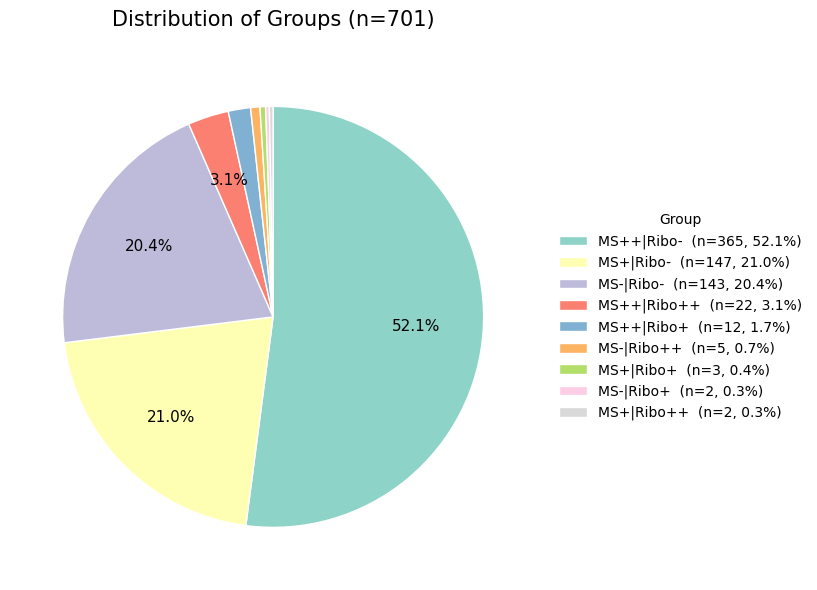

PDF已保存： /disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_group_composition.pdf


In [29]:
import matplotlib.pyplot as plt

group_counts = {
    "MS++|Ribo-": 365,
    "MS+|Ribo-": 147,
    "MS-|Ribo-": 143,
    "MS++|Ribo++": 22,
    "MS++|Ribo+": 12,
    "MS-|Ribo++": 5,
    "MS+|Ribo+": 3,
    "MS-|Ribo+": 2,
    "MS+|Ribo++": 2
}

labels = list(group_counts.keys())
values = list(group_counts.values())

# 只显示占比 ≥3% 的标签
def show_percentage(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

fig, ax = plt.subplots(figsize=(9, 6))

wedges, _, autotexts = ax.pie(
    values,
    autopct=show_percentage,
    pctdistance=0.68,
    startangle=90,
    counterclock=False,
    colors=plt.cm.Set3.colors,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1
    },
    textprops={
        "fontsize": 11
    }
)

ax.legend(
    wedges,
    [
        f"{label}  (n={value}, {value / sum(values) * 100:.1f}%)"
        for label, value in group_counts.items()
    ],
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10
)

ax.set_title(
    f"Distribution of Groups (n={sum(values)})",
    fontsize=15,
    pad=20
)

plt.tight_layout()
pdf_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_group_composition.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")
plt.show()
print("PDF已保存：", pdf_file)

,Number,Percentage (%)
Source,,
FMJC,43,6.1
Top-down,350,49.9
Bottom-up,308,43.9


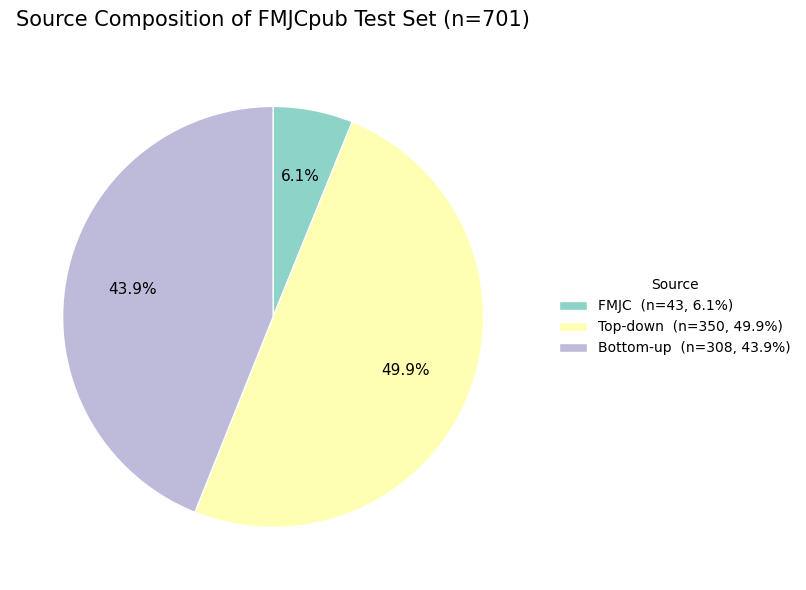

PDF已保存： /disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_source_composition.pdf


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

test_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/test_table_FMJCpub.csv.gz"
source_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/04_all_IP_exclude_stage2_deduplicated.csv"

df = pd.read_csv(test_file)
source = pd.read_csv(source_file)[["Accession", "Method"]].drop_duplicates("Accession")

df = df.merge(source, left_on="protein accession", right_on="Accession", how="left")
df = df.drop_duplicates("protein accession")

df["Source"] = df["Method"].map({
    "first_batch": "FMJC",
    "top_down": "Top-down",
    "bottom_up": "Bottom-up"
})

assert df["Source"].notna().all(), "存在未匹配来源的蛋白"

order = ["FMJC", "Top-down", "Bottom-up"]
counts = df["Source"].value_counts().reindex(order, fill_value=0)

summary = pd.DataFrame({
    "Number": counts,
    "Percentage (%)": counts / counts.sum() * 100
})
display(summary.round(1))

fig, ax = plt.subplots(figsize=(8, 6))
wedges, _, _ = ax.pie(
    counts,
    autopct=lambda x: f"{x:.1f}%",
    pctdistance=0.68,
    startangle=90,
    counterclock=False,
    colors=plt.cm.Set3.colors[:3],
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 11}
)

ax.legend(
    wedges,
    [f"{x}  (n={counts[x]}, {counts[x]/counts.sum()*100:.1f}%)" for x in order],
    title="Source",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.set_title(f"Source Composition of FMJCpub Test Set (n={counts.sum()})", fontsize=15, pad=20)
plt.tight_layout()
pdf_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/FM_pub/merged_IP_results/FMJCpub_source_composition.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")
plt.show()
print("PDF已保存：", pdf_file)

In [ ]:
###在stage2 v2的10run数据集 以及FMJCpub数据集 中测试baseline###

In [ ]:
#mipepid#
###在stage2 v2的10run数据集中测试baseline###
###在shell中运行###
cd /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid
python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/stage2_v2_10run/stage2_v2_mipepid_10runs_v2/run_stage2_mipepid_10runs.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --mipepid_script /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid/src/mipepid.py \
  --out_root /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/stage2_v2/mipepid/stage2_10runs \
  --start_run 0 \
  --n_runs 10 \
  --threshold 0.5 \
  --skip_existing

###在FMJCpub数据集 中测试baseline###
python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/FMJCpub/mipepid_fmjcpub_external_v1/run_mipepid_fmjcpub.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.pkl \
  --mipepid_script /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid/src/mipepid.py \
  --out_dir /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/stage2_v2/mipepid/FMJCpub_external \
  --seq_col orf_seq \
  --label_col binary_label \
  --positive_value 1 \
  --threshold 0.5 \
  --require_atg \
  --skip_existing

In [ ]:
#sOCP#
###在stage2 v2的10run数据集中测试baseline###
conda activate sOCP

cd /disk3/hejp/00_thesis/4_predict_translation/model/sOCP

python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/stage2_v2_10run/stage2_v2_socp_10runs_v1/run_stage2_socp_10runs_csv.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --dataset_prefix translation_strict_lenmatched \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --socp_script /disk3/hejp/00_thesis/4_predict_translation/model/sOCP/PredictingCodingPotential.py \
  --model_dir /disk3/hejp/00_thesis/4_predict_translation/model/sOCP/HumanModel \
  --out_root /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/stage2_v2/sOCP/stage2_10runs \
  --start_run 0 \
  --n_runs 10 \
  --threshold 0.5 \
  --skip_existing
###在FMJCpub数据集 中测试baseline###
python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/FMJCpub/socp_fmjcpub_external_v1/run_socp_fmjcpub_csv.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.csv.gz \
  --socp_script /disk3/hejp/00_thesis/4_predict_translation/model/sOCP/PredictingCodingPotential.py \
  --model_dir /disk3/hejp/00_thesis/4_predict_translation/model/sOCP/HumanModel \
  --out_dir /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/stage2_v2/sOCP/FMJCpub_external \
  --seq_col orf_seq \
  --upstream_col auto \
  --label_col binary_label \
  --positive_value 1 \
  --threshold 0.5 \
  --skip_existing

In [33]:
###在FMJCpub数据集中测试 position enhanced CNN###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/stage2_ep_fmjcpub_external_v1/predict_fmjcpub_enhanced_position_10runs.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.pkl \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_tuning_v1/train_stage2_rnaesm_cnn_tuned_v1.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs/FMJCpub_external \
  --config_name enhanced_position \
  --label_col binary_label \
  --positive_value 1 \
  --expected_models 10 \
  --threshold 0.5 \
  --batch_size 512 \
  --num_workers 2 \
  --skip_existing

FMJCpub samples: 1190
Label counts: {0: 655, 1: 535}
Embedding columns: {'rna_up': 'rnafm_up_path', 'rna_orf': 'rnafm_orf_path', 'rna_down': 'rnafm_down_path', 'esm2': 'esm2_path'}
Checkpoints: 10
Device: cuda

Run 00: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs/enhanced_position/cnn_enhanced_position_run00/cnn_enhanced_position_run00_best_model.pt
  ROC-AUC=0.7564, AUPR=0.7465

Run 01: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs/enhanced_position/cnn_enhanced_position_run01/cnn_enhanced_position_run01_best_model.pt
  ROC-AUC=0.7686, AUPR=0.7623

Run 02: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_rnaesm_cnn_enhanced_position_10runs/enhanced_position/cnn_enhanced_position_run02/cnn_enhanced_position_

In [34]:
###在FMJCpub数据集中测试其他的baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_baselines/stage2_rnaesm_baselines_fmjcpub_external_v1/predict_fmjcpub_stage2_rnaesm_baselines_10runs.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.pkl \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_rnaesm_baselines/train_stage2_rnaesm_baseline_v4.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/FMJCpub_external \
  --models transformer cnn mlp lr rf lgbm \
  --start_run 0 \
  --n_runs 10 \
  --label_col binary_label \
  --positive_value 1 \
  --threshold 0.5 \
  --batch_size 512 \
  --cnn_batch_size 16 \
  --transformer_batch_size 16 \
  --num_workers 2 \
  --skip_existing

FMJCpub samples: 1190
Label counts: {0: 655, 1: 535}
Embedding columns: {'rna_up': 'rnafm_up_path', 'rna_orf': 'rnafm_orf_path', 'rna_down': 'rnafm_down_path', 'esm2': 'esm2_path'}
Models: ['transformer', 'cnn', 'mlp', 'lr', 'rf', 'lgbm']
Runs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Device: cuda
Pooled FMJCpub features: 1000/1190
Pooled FMJCpub features: 1190/1190
Saved pooled feature cache: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/FMJCpub_external/fmjcpub_meanmax_features.npz
Pooled feature shapes: (1190, 3840) (1190, 2560)

Model: Transformer
run00: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/transformer/transformer_run00/transformer_run00_best_model.pt
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stag

In [35]:
###在stage2v2和FMJCpub数据集中测试stage1的Transformer ep模型###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage1_trans_stage2v2_fmjcpub_v1/evaluate_stage1_enhanced_position_on_stage2v2_and_fmjcpub.py \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc \
  --run_name_prefix rnafm_self_attention_enhanced_position_select_strict_roc \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs \
  --stage2_dataset_prefix translation_strict_lenmatched \
  --stage2_dataset_suffix .pkl \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage2_v2_rnaesm_baselines_10runs/generated_splits \
  --fmjcpub_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/FMJCpub_independent/FMJCpub_MS_pos_ribotricer_neg_with_rnafm_esm2_paths.pkl \
  --stage1_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --stage1_dataset_prefix translation_strict_lenmatched \
  --stage1_dataset_suffix .pkl \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage1_transep_stage2_v2_and_fmjcpub \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --threshold 0.5 \
  --batch_size 64 \
  --num_workers 2 \
  --skip_existing

Device: cuda
Input: RNA-FM only; no ESM2/protein features
Padding: upstream=left, ORF=right, downstream=right
FMJCpub: (1190, 17); RNA-FM dimension=640

Run 00
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage1_trans_stage2v2_fmjcpub_v1/build_model_rnafm_self_attention_enhanced_position.py:138: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
Stage2_v2 run00: AUROC=0.6261, AUPR=0.6178
FMJCpub model run00: AUROC=0.5480, AUPR=0.5172

Run 01
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage1_trans_stage2v2_fmjcpub_v1/build_model_rnafm_self_attention_enhanced_position.py:138: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder

In [37]:
###可视化所有模型的结果 stage2v2###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_model_comparison_v1_20260805/build_stage2_model_prediction_manifest.py

OK  stage2_internal_test   RNA-FM + ESM2 CNN enhanced position      files=10
OK  stage2_internal_test   RNA-FM + ESM2 Transformer                files=10
OK  stage2_internal_test   RNA-FM + ESM2 CNN                        files=10
OK  stage2_internal_test   RNA-FM + ESM2 pooled MLP                 files=10
OK  stage2_internal_test   RNA-FM + ESM2 LR                         files=10
OK  stage2_internal_test   RNA-FM + ESM2 RF                         files=10
OK  stage2_internal_test   RNA-FM + ESM2 LGBM                       files=10
OK  stage2_internal_test   Stage1 RNA-only Transformer              files=10
OK  stage2_internal_test   MiPepid                                  files=10
OK  stage2_internal_test   sOCP                                     files=10
OK  fmjcpub_external       RNA-FM + ESM2 CNN enhanced position      files=1
OK  fmjcpub_external       RNA-FM + ESM2 Transformer                files=1
OK  fmjcpub_external       RNA-FM + ESM2 CNN                        files=1
OK

In [38]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/stage2_model_comparison_v1_20260805/make_stage2_model_summary_and_curves.py \
  --manifest /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/model_comparison_stage2_v1/stage2_model_prediction_manifest.csv \
  --outdir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/model_comparison_stage2_v1 \
  --threshold 0.5 \
  --dataset_order stage2_internal_test,fmjcpub_external \
  --title_prefix "MS supported microprotein prediction"

Saved outputs to: /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_v2_MSpp_ribotricer/model_comparison_stage2_v1
             dataset                               model     n      Accuracy     Precision        Recall            F1         AUROC          AUPR            MCC
stage2_internal_test RNA-FM + ESM2 CNN enhanced position 44100 0.716 ± 0.013 0.748 ± 0.029 0.660 ± 0.086 0.697 ± 0.037 0.804 ± 0.006 0.797 ± 0.007  0.440 ± 0.020
stage2_internal_test           RNA-FM + ESM2 Transformer 44100 0.695 ± 0.012 0.696 ± 0.021 0.696 ± 0.036 0.695 ± 0.013 0.764 ± 0.012 0.728 ± 0.015  0.390 ± 0.023
stage2_internal_test                   RNA-FM + ESM2 CNN 44100 0.717 ± 0.012 0.707 ± 0.032 0.753 ± 0.066 0.726 ± 0.014 0.798 ± 0.007 0.790 ± 0.007  0.440 ± 0.016
stage2_internal_test            RNA-FM + ESM2 pooled MLP 44100 0.662 ± 0.006 0.643 ± 0.018 0.735 ± 0.065 0.684 ± 0.019 0.731 ± 0.006 0.706 ± 0.007  0.331 ± 0.013
stage2_i